# Notebook 01 — Разведочный анализ данных (EDA)

**Требует:** `data/features.parquet` из `notebook_02_metrics.ipynb`

**Цель:** изучить структуру 23 метрик до кластеризации.

1. Распределения и нормальность метрик
2. Выбросы и аномальные акции
3. Корреляции внутри и между группами
4. PCA — эффективная размерность данных
5. t-SNE / UMAP — визуальная структура до кластеризации
6. Метрики по секторам — экономическая осмысленность

In [8]:
import warnings
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi'       : 150,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'figure.facecolor' : 'white',
    'font.size'        : 10,
})

df   = pd.read_parquet('data/features.parquet')
meta = pd.read_csv('data/sp500_meta.csv', index_col='ticker')
df   = df.join(meta[['sector', 'name']], how='left')

# ── Группы метрик (15 финальных) ─────────────────────────────────
FEATURE_GROUPS = {
    'risk'  : ['sigma', 'beta', 'max_dd'],
    'return': ['sharpe', 'mom_12m', 'win_rate'],
    'sector': ['corr_sector', 'beta_sector', 'corr_residual'],
    'market': ['corr_sp500', 'corr_calm', 'tail_dependence'],
}

ALL_FEATURES = (
    FEATURE_GROUPS['risk']   +
    FEATURE_GROUPS['return'] +
    FEATURE_GROUPS['sector'] +
    FEATURE_GROUPS['market']
)

LABELS = {
    # Группа 1 — Риск
    'sigma'          : 'Волатильность (σ)',
    'beta'           : 'Бета (β)',
    'max_dd'         : 'Макс. просадка',
    # Группа 2 — Доходность
    'sharpe'         : 'Шарп',
    'mom_12m'        : 'Моментум 12М',
    'win_rate'       : 'Win Rate',
    # Группа 3 — Секторальная независимость
    'corr_sector'    : 'Корр. с сектором',
    'beta_sector'    : 'Бета к сектору',
    'corr_residual'  : 'Корр. остатков',
    # Группа 4 — Межрыночные
    'corr_sp500'     : 'Корр. S&P 500',
    'corr_calm'      : 'Корр. (спокойный)',
    'tail_dependence': 'Tail Dependence',
}

GROUP_NAMES = {
    'risk'  : 'Группа 1: Риск',
    'return': 'Группа 2: Доходность',
    'sector': 'Группа 3: Секторальная независимость',
    'market': 'Группа 4: Межрыночные',
}

# ── Удалённые метрики и причины исключения ────────────────────────
EXCLUDED = {
    'cvar_95'      : '|ρ|=0.99 с σ — дублирует волатильность',
    'info_ratio'   : '|ρ|=0.96 с Sharpe — дублирует',
    'mom_1m'       : 'краткосрочный разворот, |ρ|=0.91 с mom_12m',
    'hurst'        : 'H∈[0.52,0.58] у всех акций — нет вариации',
    'ac_lag1'      : 'удалено вместе с группой Динамика',
    'ac_lag5'      : 'удалено вместе с группой Динамика',
    'kurtosis'     : 'удалено вместе с группой Динамика',
    'skewness'     : 'удалено вместе с группой Динамика',
    'variance_ratio': 'удалено вместе с группой Динамика',
    'corr_stress'  : '|ρ|=0.97 с corr_sp500 — дублирует',
    'r_squared'    : 'удалено как дублирующее corr_sp500²',
}

print(f"Акций: {len(df)} | Финальных метрик: {len(ALL_FEATURES)}")
print(f"Групп: {len(FEATURE_GROUPS)}")
for grp, feats in FEATURE_GROUPS.items():
    print(f"  {GROUP_NAMES[grp]}: {feats}")
print(f"\nИсключено метрик: {len(EXCLUDED)}")
for feat, reason in EXCLUDED.items():
    print(f"  {feat}: {reason}")

Акций: 481 | Финальных метрик: 12
Групп: 4
  Группа 1: Риск: ['sigma', 'beta', 'max_dd']
  Группа 2: Доходность: ['sharpe', 'mom_12m', 'win_rate']
  Группа 3: Секторальная независимость: ['corr_sector', 'beta_sector', 'corr_residual']
  Группа 4: Межрыночные: ['corr_sp500', 'corr_calm', 'tail_dependence']

Исключено метрик: 11
  cvar_95: |ρ|=0.99 с σ — дублирует волатильность
  info_ratio: |ρ|=0.96 с Sharpe — дублирует
  mom_1m: краткосрочный разворот, |ρ|=0.91 с mom_12m
  hurst: H∈[0.52,0.58] у всех акций — нет вариации
  ac_lag1: удалено вместе с группой Динамика
  ac_lag5: удалено вместе с группой Динамика
  kurtosis: удалено вместе с группой Динамика
  skewness: удалено вместе с группой Динамика
  variance_ratio: удалено вместе с группой Динамика
  corr_stress: |ρ|=0.97 с corr_sp500 — дублирует
  r_squared: удалено как дублирующее corr_sp500²


In [14]:
import pandas as pd
import numpy as np
import yfinance as yf
from scipy import stats

# ── ETF по секторам GICS ──────────────────────────────────────────
SECTOR_ETF = {
    'Information Technology'  : 'XLK',
    'Health Care'             : 'XLV',
    'Financials'              : 'XLF',
    'Energy'                  : 'XLE',
    'Consumer Discretionary'  : 'XLY',
    'Consumer Staples'        : 'XLP',
    'Industrials'             : 'XLI',
    'Materials'               : 'XLB',
    'Real Estate'             : 'XLRE',
    'Utilities'               : 'XLU',
    'Communication Services'  : 'XLC',
}

START, END = '2019-01-01', '2024-12-31'

df       = pd.read_parquet('data/features.parquet')
meta     = pd.read_csv('data/sp500_meta.csv', index_col='ticker')
df       = df.join(meta[['sector', 'name']], how='left')

# ── Загружаем цены акций и ETF ────────────────────────────────────
tickers  = list(df.index)
etfs     = list(SECTOR_ETF.values()) + ['^GSPC']
all_tick = tickers + etfs

print(f"Загружаем {len(all_tick)} тикеров...")
raw = yf.download(all_tick, start=START, end=END,
                  auto_adjust=True, progress=False)['Close']
rets = np.log(raw / raw.shift(1)).dropna()
print(f"Загружено: {rets.shape[0]} торговых дней")

# ── Рассчитываем секторальные метрики ─────────────────────────────
records = {}
sp500   = rets['^GSPC']

for ticker in tickers:
    sector = df.loc[ticker, 'sector'] if ticker in df.index else None
    etf    = SECTOR_ETF.get(sector)

    if etf is None or ticker not in rets.columns or etf not in rets.columns:
        records[ticker] = {'corr_sector': np.nan,
                           'beta_sector': np.nan,
                           'corr_residual': np.nan}
        continue

    r_i   = rets[ticker].dropna()
    r_s   = rets[etf].dropna()
    r_m   = sp500.dropna()

    # Общий индекс
    idx   = r_i.index.intersection(r_s.index).intersection(r_m.index)
    if len(idx) < 100:
        records[ticker] = {'corr_sector': np.nan,
                           'beta_sector': np.nan,
                           'corr_residual': np.nan}
        continue

    r_i, r_s, r_m = r_i[idx], r_s[idx], r_m[idx]

    # corr_sector — корреляция Пирсона с ETF сектора
    corr_sector = r_i.corr(r_s)

    # beta_sector — β регрессии акции на ETF сектора
    slope, _, _, _, _ = stats.linregress(r_s, r_i)
    beta_sector = slope

    # corr_residual — корреляция остатков акции на ETF
    # с остатками ETF на S&P 500
    res_i = r_i - (slope * r_s)                          # остатки акции
    slope_s, _, _, _, _ = stats.linregress(r_m, r_s)
    res_s = r_s - (slope_s * r_m)                        # остатки ETF
    corr_residual = res_i.corr(res_s)

    records[ticker] = {
        'corr_sector'  : corr_sector,
        'beta_sector'  : beta_sector,
        'corr_residual': corr_residual,
    }

df_sector = pd.DataFrame(records).T
df_sector.index.name = 'ticker'

print(f"\nРассчитано для {df_sector.notna().all(axis=1).sum()} акций")
print(df_sector.describe().round(3))

# ── Сохраняем ─────────────────────────────────────────────────────
df_sector.to_parquet('data/features_sector.parquet')
print("\nСохранено: data/features_sector.parquet")

# ── Добавляем в основной df для текущей сессии ────────────────────
for col in ['corr_sector', 'beta_sector', 'corr_residual']:
    df[col] = df_sector[col]

print("✓ Колонки добавлены в df")

Загружаем 493 тикеров...
Загружено: 1455 торговых дней

Рассчитано для 481 акций
       corr_sector  beta_sector  corr_residual
count      481.000      481.000        481.000
mean         0.677        0.997         -0.062
std          0.131        0.240          0.155
min          0.210        0.330         -0.444
25%          0.588        0.842         -0.157
50%          0.676        0.988         -0.053
75%          0.782        1.126          0.051
max          0.934        2.257          0.332

Сохранено: data/features_sector.parquet
✓ Колонки добавлены в df


In [16]:
import pandas as pd

# Проверяем что в файле
df_sector = pd.read_parquet('data/features_sector.parquet')
print("Колонки:", df_sector.columns.tolist())
print("Строк:", len(df_sector))
print("NaN:", df_sector.isna().sum())
print(df_sector.head(3))

Колонки: ['corr_sector', 'beta_sector', 'corr_residual']
Строк: 481
NaN: corr_sector      0
beta_sector      0
corr_residual    0
dtype: int64
        corr_sector  beta_sector  corr_residual
ticker                                         
A          0.689345     1.134798      -0.204967
AAPL       0.853320     0.977626       0.047122
ABBV       0.618586     0.887315       0.108360


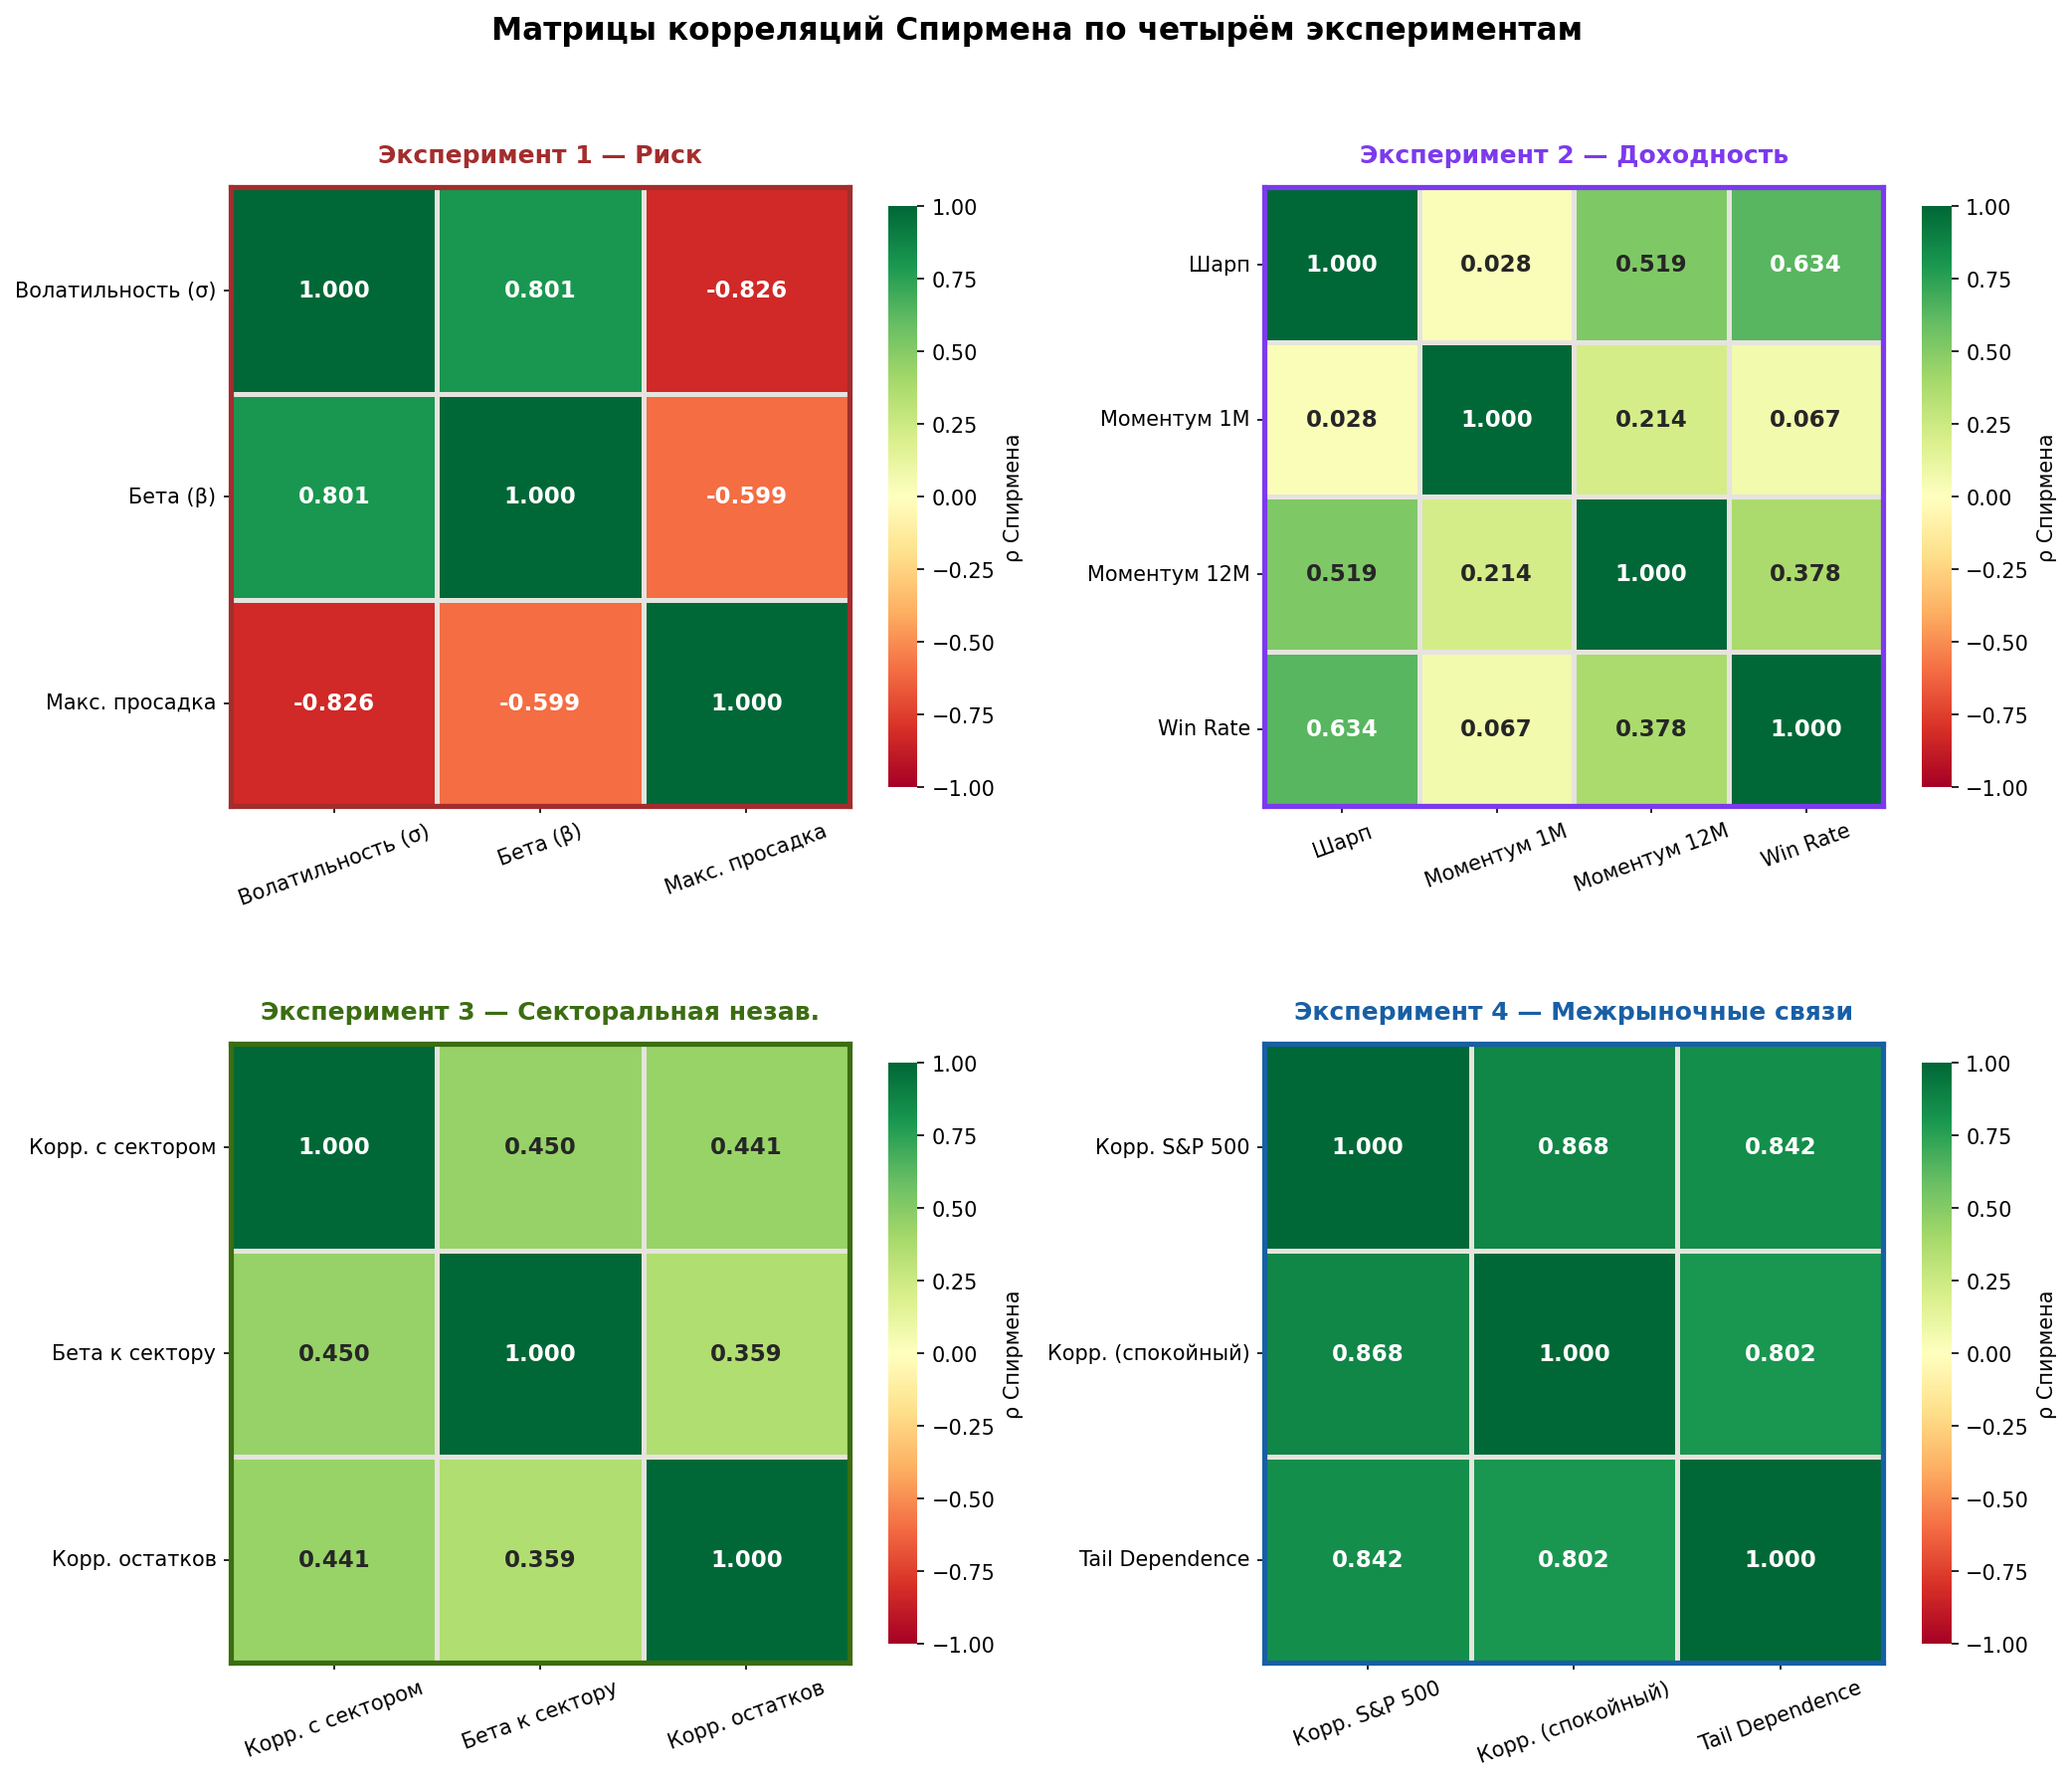

Сохранено: corr_matrices_4exp.png


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_parquet('data/features.parquet')
meta = pd.read_csv('data/sp500_meta.csv', index_col='ticker')
df = df.join(meta[['sector', 'name']], how='left')

# ── Добавляем секторальные метрики ────────────────────────────────
df_sector = pd.read_parquet('data/features_sector.parquet')
df[['corr_sector', 'beta_sector', 'corr_residual']] = df_sector

GROUPS = {
    'Эксперимент 1 — Риск':                  ['sigma', 'beta', 'max_dd'],
    'Эксперимент 2 — Доходность':            ['sharpe', 'mom_1m', 'mom_12m', 'win_rate'],
    'Эксперимент 3 — Секторальная незав.':   ['corr_sector', 'beta_sector', 'corr_residual'],
    'Эксперимент 4 — Межрыночные связи':     ['corr_sp500', 'corr_calm', 'tail_dependence'],
}

LABELS = {
    'sigma'          : 'Волатильность (σ)',
    'beta'           : 'Бета (β)',
    'max_dd'         : 'Макс. просадка',
    'sharpe'         : 'Шарп',
    'mom_1m'         : 'Моментум 1М',
    'mom_12m'        : 'Моментум 12М',
    'win_rate'       : 'Win Rate',
    'corr_sector'    : 'Корр. с сектором',
    'beta_sector'    : 'Бета к сектору',
    'corr_residual'  : 'Корр. остатков',
    'corr_sp500'     : 'Корр. S&P 500',
    'corr_calm'      : 'Корр. (спокойный)',
    'tail_dependence': 'Tail Dependence',
}

# Цвета рамок по экспериментам
COLORS = {
    'Эксперимент 1 — Риск'              : '#A32D2D',
    'Эксперимент 2 — Доходность'        : '#7C3AED',
    'Эксперимент 3 — Секторальная незав.': '#3B6D11',
    'Эксперимент 4 — Межрыночные связи' : '#185FA5',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (title, feats) in enumerate(GROUPS.items()):
    ax = axes[idx]
    col = COLORS[title]

    # Берём только доступные метрики
    avail = [f for f in feats if f in df.columns]
    missing = [f for f in feats if f not in df.columns]
    if missing:
        print(f"⚠  {title}: отсутствуют {missing}")

    if len(avail) < 2:
        ax.text(0.5, 0.5, f"Недостаточно данных\n({avail})",
                ha='center', va='center', transform=ax.transAxes,
                fontsize=12, color='#9e9c97')
        ax.set_title(title, fontsize=12, fontweight='bold', color=col, pad=12)
        continue

    corr = df[avail].corr(method='spearman')
    corr.index   = [LABELS.get(c, c) for c in corr.index]
    corr.columns = [LABELS.get(c, c) for c in corr.columns]

    sns.heatmap(
        corr, ax=ax,
        cmap='RdYlGn', vmin=-1, vmax=1, center=0,
        annot=True, fmt='.3f', annot_kws={'size': 11, 'fontweight': 'bold'},
        linewidths=1.5, linecolor='#e6e4de',
        square=True,
        cbar_kws={'shrink': 0.8, 'label': 'ρ Спирмена'},
    )

    # Рамка цветом эксперимента
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(col)
        spine.set_linewidth(2.5)

    ax.set_title(title, fontsize=12, fontweight='bold', color=col, pad=12)
    ax.tick_params(axis='x', rotation=20, labelsize=10)
    ax.tick_params(axis='y', rotation=0,  labelsize=10)

fig.suptitle(
    'Матрицы корреляций Спирмена по четырём экспериментам',
    fontsize=15, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('corr_matrices_4exp.png', dpi=150, bbox_inches='tight')
plt.show()
print("Сохранено: corr_matrices_4exp.png")

## 1. Описательная статистика

In [ ]:
desc = df[ALL_FEATURES].describe().round(4)
desc.columns = [LABELS.get(c, c) for c in desc.columns]
print("Описательная статистика (23 метрики):")
desc

KeyError: "['corr_sector', 'beta_sector', 'corr_residual'] not in index"

## 2. Распределения всех метрик

Тест Шапиро-Уилка на нормальность.
Результат обосновывает выбор RobustScaler и метрики Спирмена.

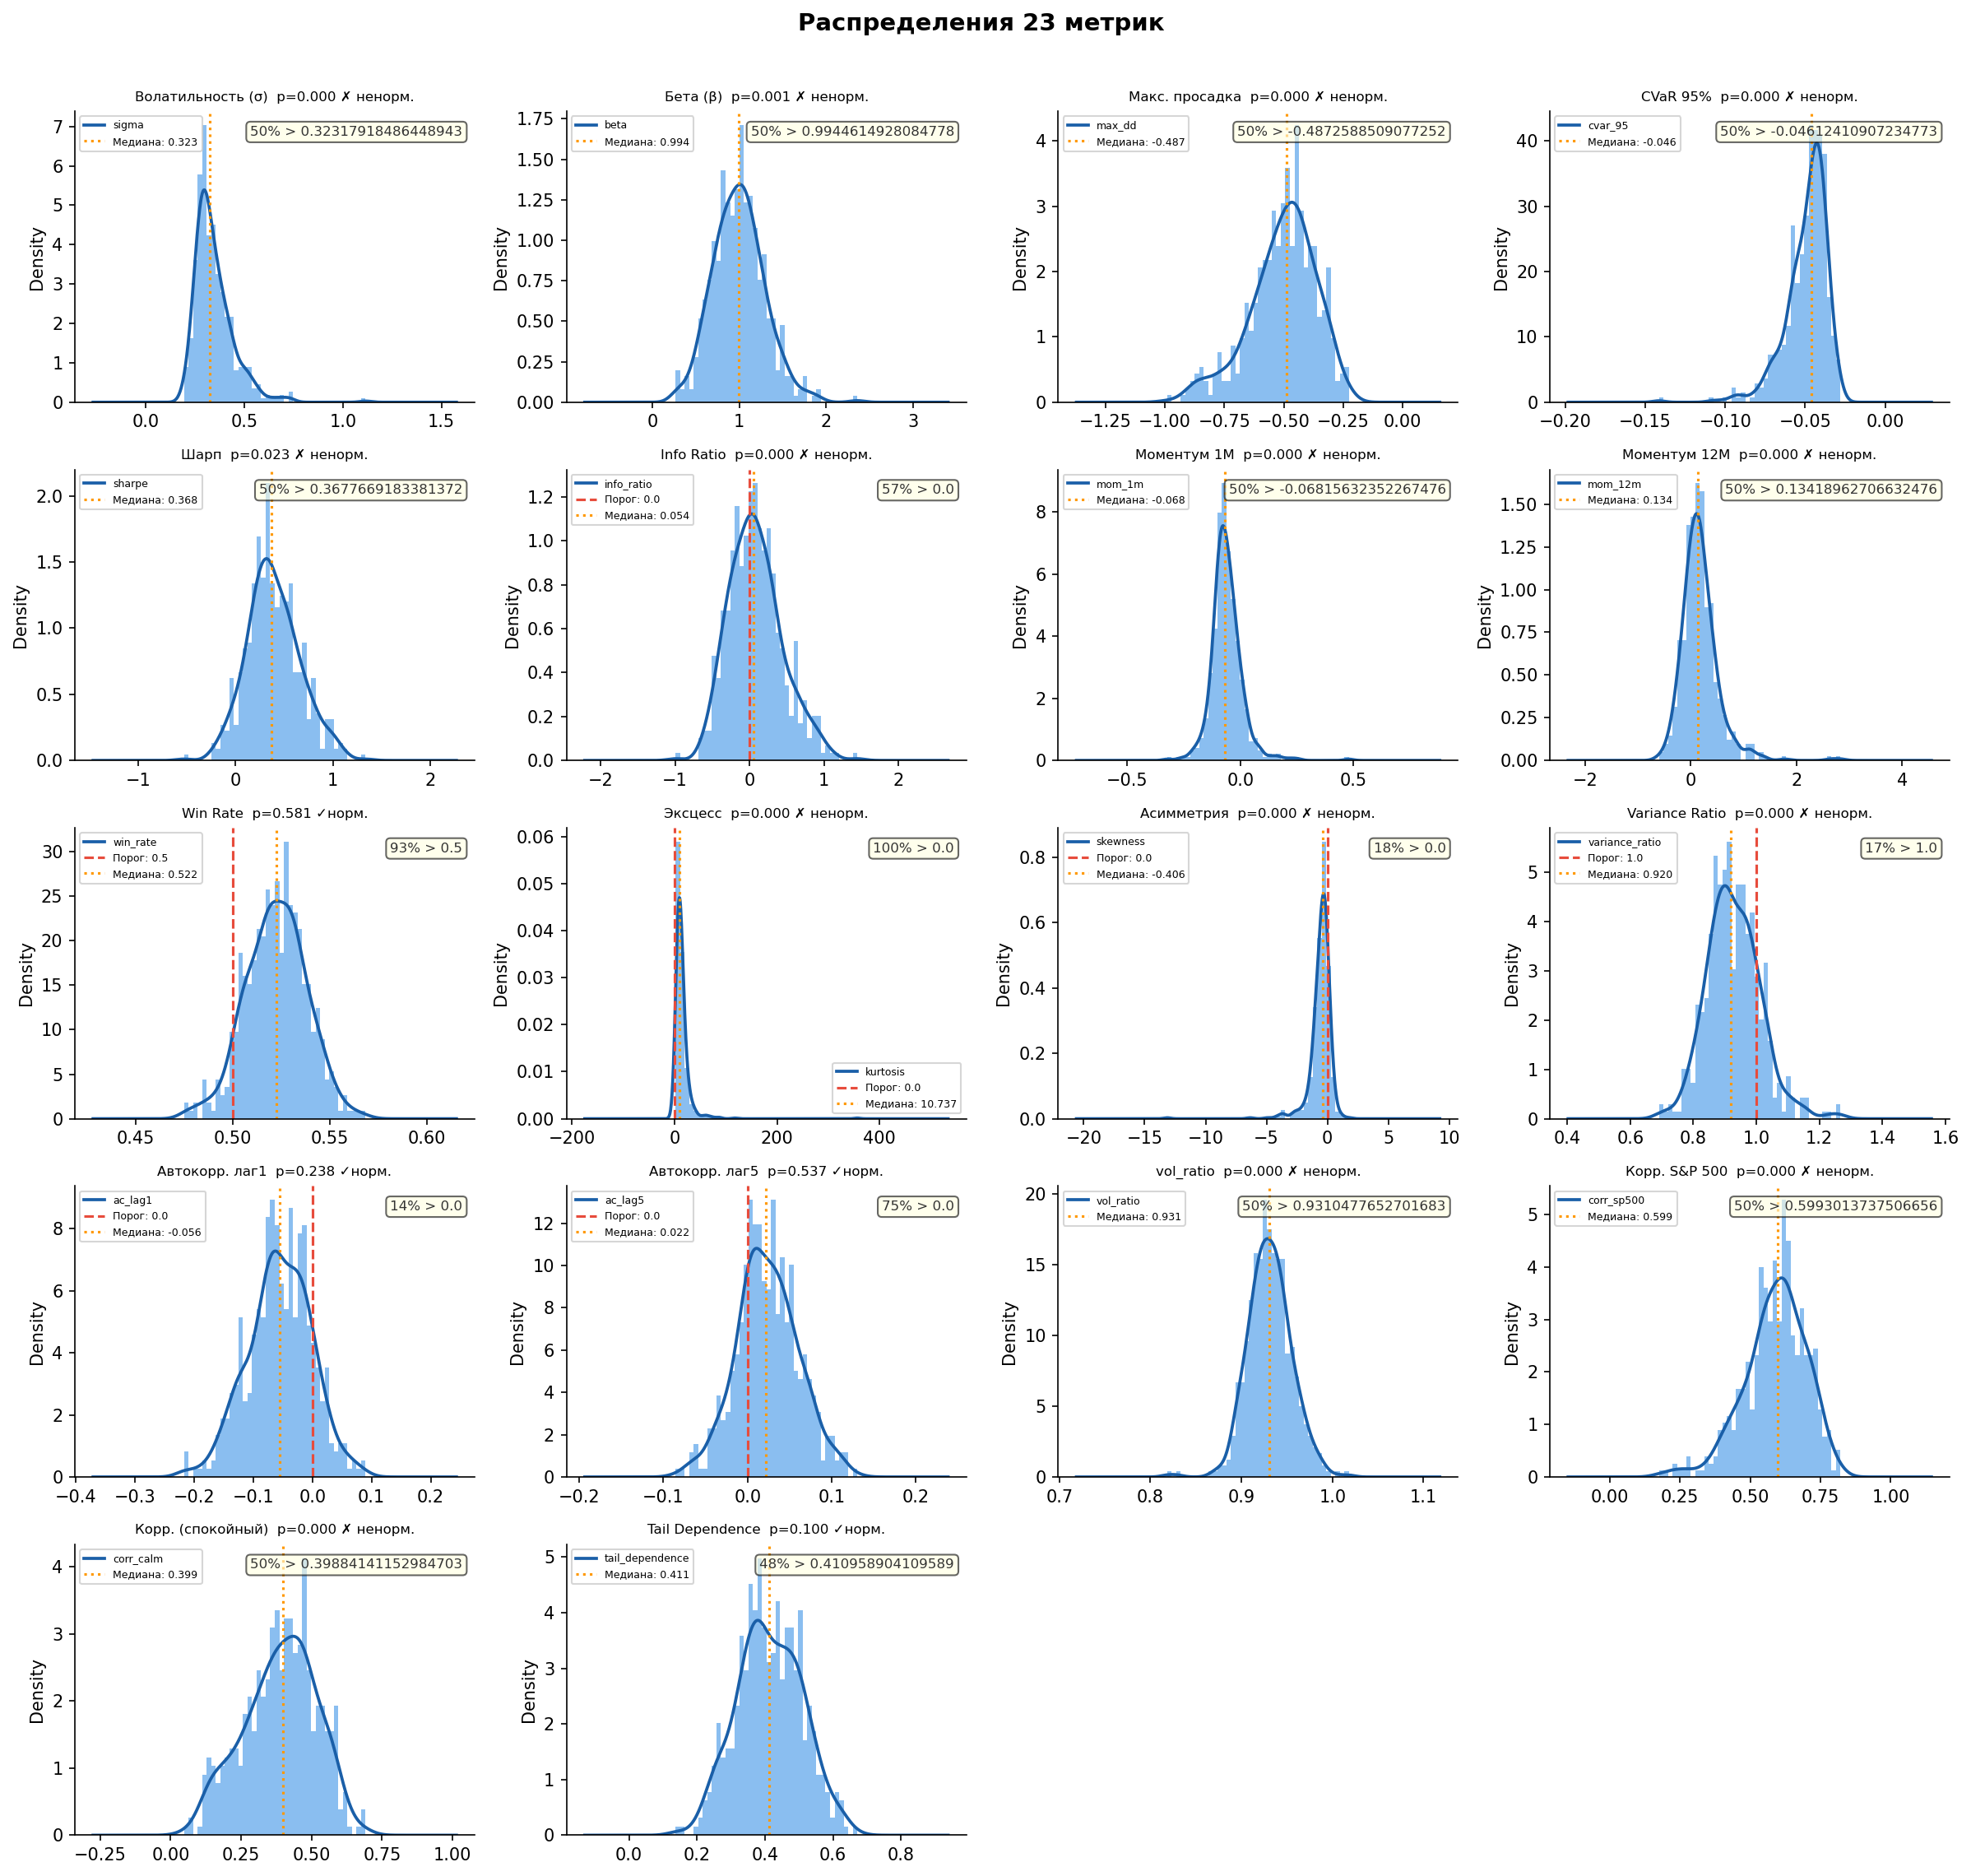

Нормальных метрик:    4/18
Ненормальных метрик:  14/18
→ Обоснование RobustScaler и корреляции Спирмена


In [ ]:
n_cols = 4
n_rows = (len(ALL_FEATURES) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
fig.suptitle('Распределения 23 метрик', fontsize=14, fontweight='bold', y=1.01)
axes_flat = axes.flatten()

normality = {}

# Теоретические пороги для метрик с осмысленным нулём
thresholds = {
    'hurst'         : 0.5,
    'ac_lag1'       : 0.0,
    'ac_lag5'       : 0.0,
    'skewness'      : 0.0,
    'kurtosis'      : 0.0,
    'variance_ratio': 1.0,
    'win_rate'      : 0.5,
    'info_ratio'    : 0.0,
}

for i, feat in enumerate(ALL_FEATURES):
    ax   = axes_flat[i]
    data = df[feat].dropna()

    ax.hist(data, bins=40, color='#4C9BE8', alpha=0.65,
            edgecolor='none', density=True)
    try:
        data.plot.kde(ax=ax, color='#1a5fa8', linewidth=1.8)
    except Exception:
        pass

    # Теоретический порог
    if feat in thresholds:
        ax.axvline(thresholds[feat], color='#e74c3c',
                   linestyle='--', linewidth=1.5,
                   label=f'Порог: {thresholds[feat]}')

    ax.axvline(data.median(), color='#FF9800', linestyle=':',
               linewidth=1.5, label=f'Медиана: {data.median():.3f}')

    # Тест нормальности
    sample = data.sample(min(len(data), 5000), random_state=42)
    _, pv  = stats.shapiro(sample)
    normality[feat] = pv > 0.05

    # % выше порога
    thr = thresholds.get(feat, data.median())
    pct = (data > thr).mean() * 100
    ax.text(0.97, 0.95, f'{pct:.0f}% > {thr}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=8, color='#333',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.6))

    norm_label = '✓норм.' if normality[feat] else '✗ ненорм.'
    ax.set_title(f"{LABELS.get(feat, feat)}  p={pv:.3f} {norm_label}",
                 fontsize=8)
    ax.legend(fontsize=6)

for j in range(i+1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.savefig('plots/01_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

n_normal = sum(normality.values())
print(f"Нормальных метрик:    {n_normal}/{len(ALL_FEATURES)}")
print(f"Ненормальных метрик:  {len(ALL_FEATURES)-n_normal}/{len(ALL_FEATURES)}")
print("→ Обоснование RobustScaler и корреляции Спирмена")

## 3. Выбросы по группам

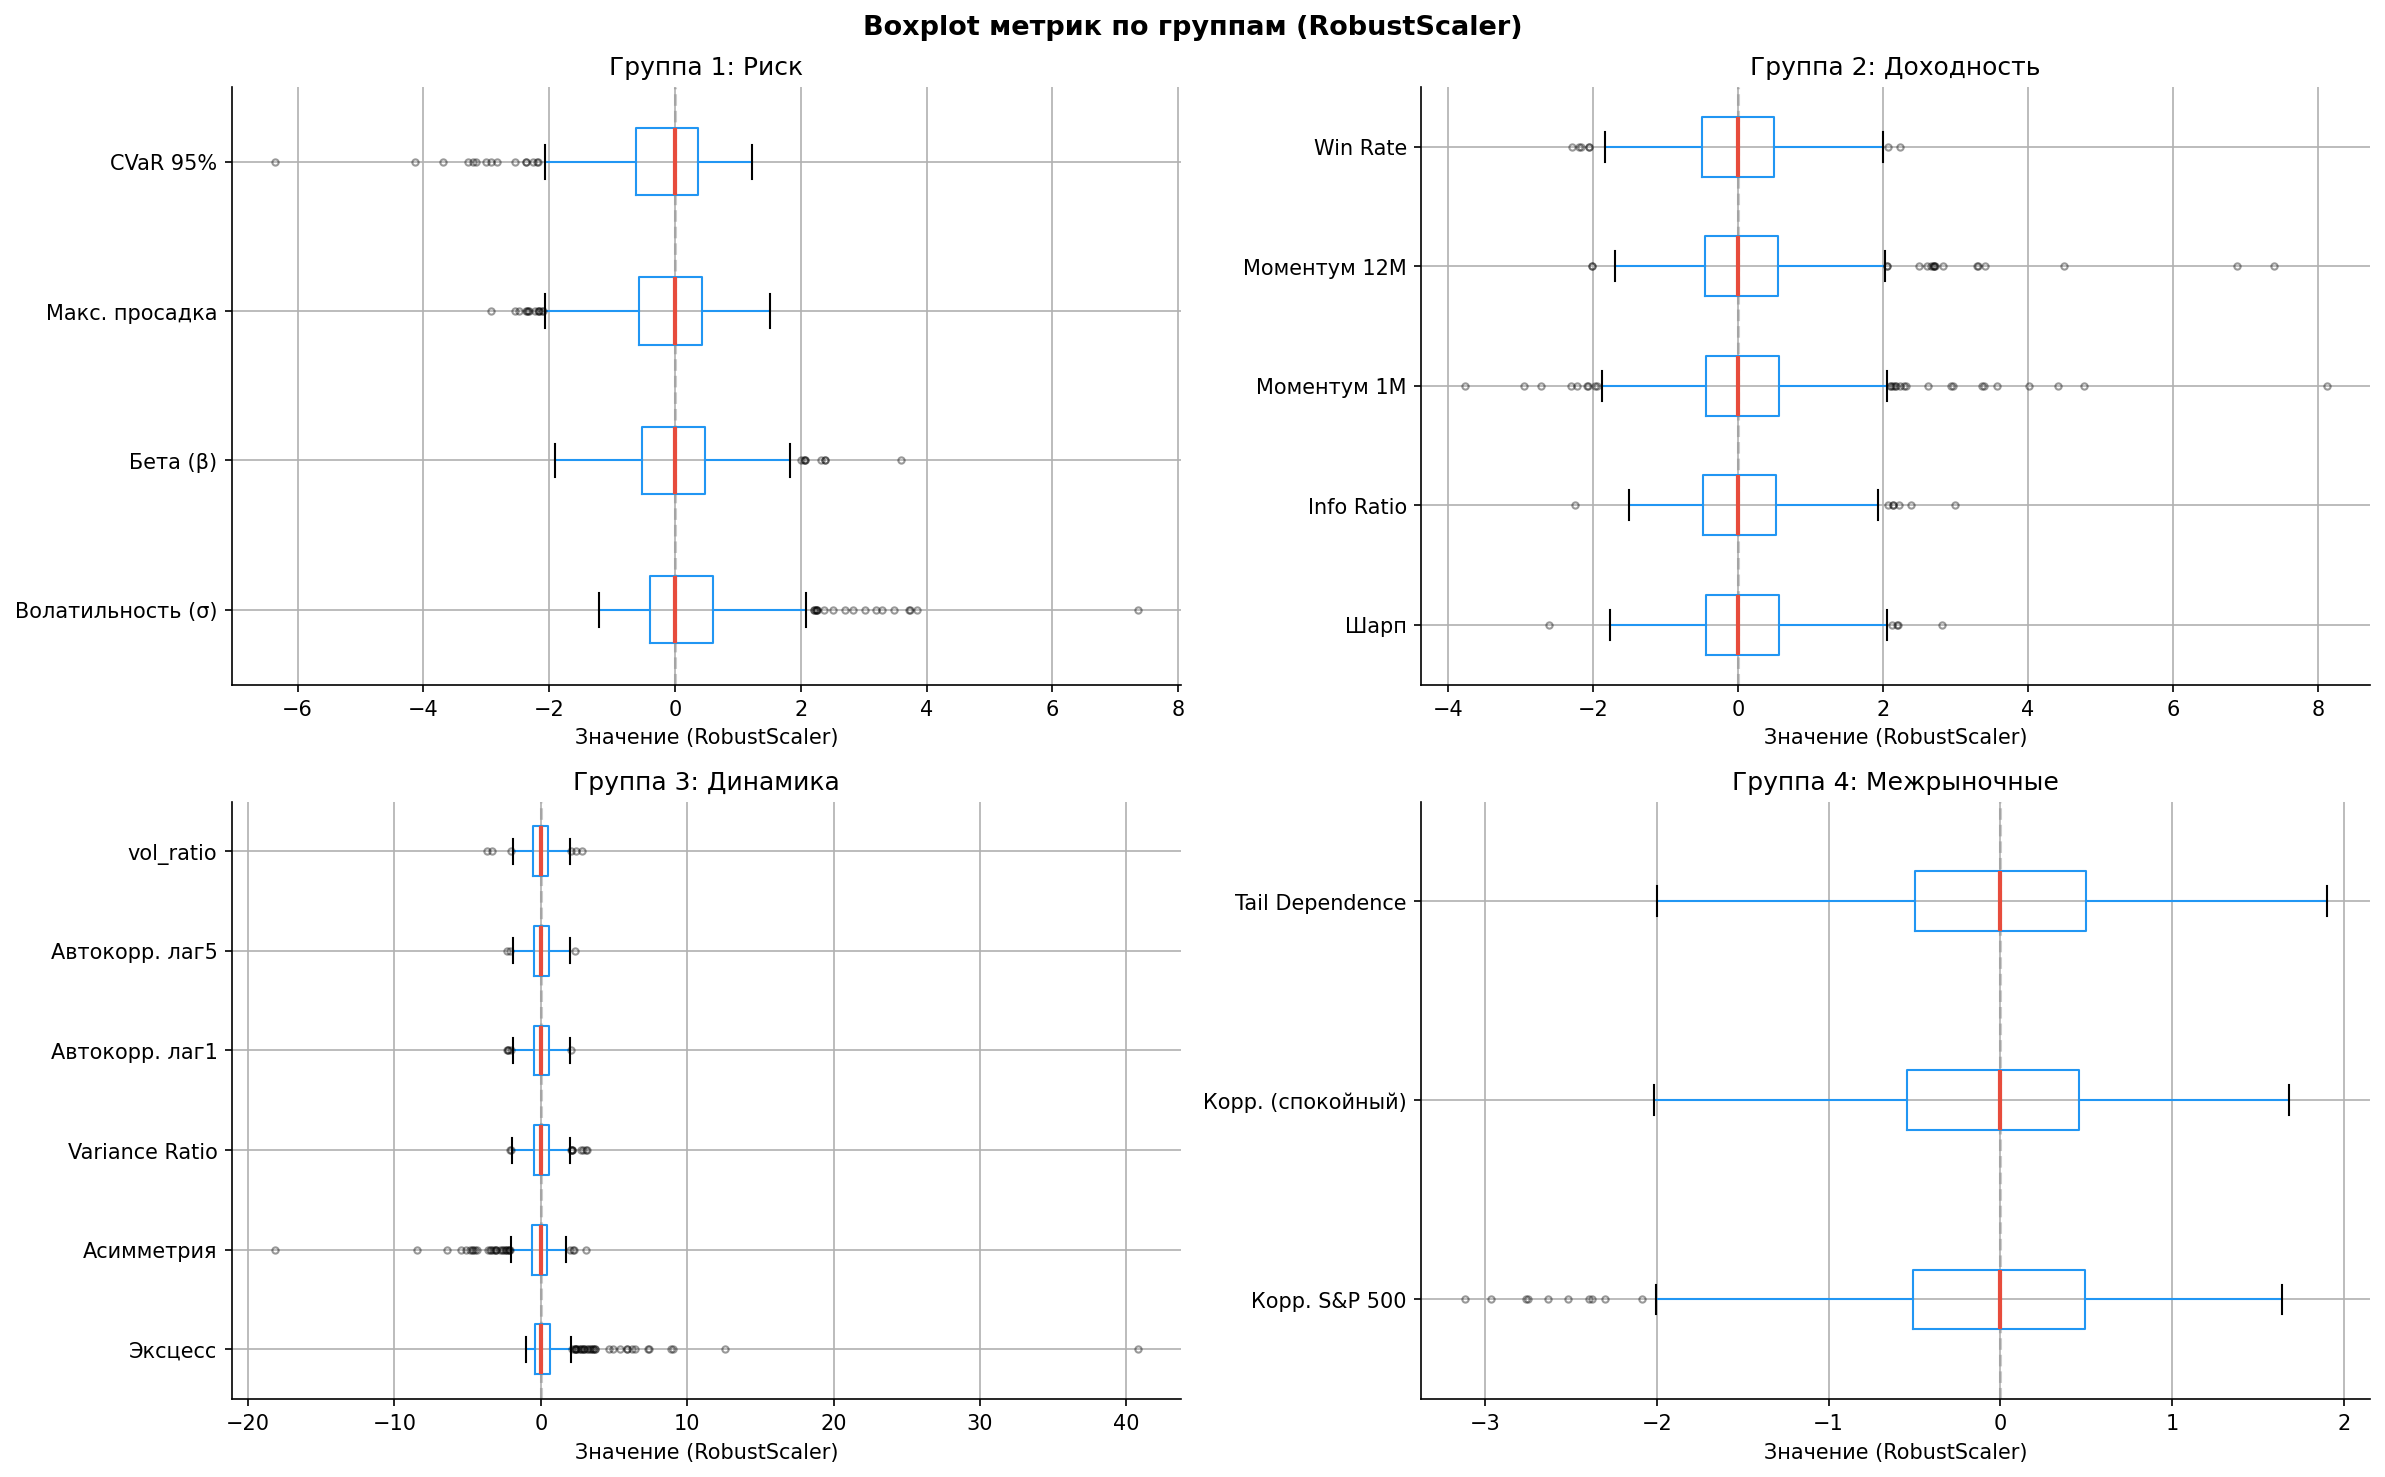

Топ-5 выбросов по ключевым метрикам:
  Волатильность (σ)     : CVNA(1.115), NCLH(0.738), MRNA(0.726), SMCI(0.724), CCL(0.698)
  CVaR 95%              : JNJ(-0.028), CL(-0.029), BRK-B(-0.029), WMT(-0.029), PEP(-0.030)
  Эксцесс               : GL(356.494), TRGP(117.699), OXY(87.350), DG(86.185), EPAM(73.486)
  Хёрст (H)             : ERIE(0.640), ABBV(0.640), PSX(0.630), TSLA(0.629), SHW(0.628)
  Tail Dependence       : ACN(0.671), MSFT(0.644), APH(0.630), GOOG(0.630), GOOGL(0.630)


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Boxplot метрик по группам (RobustScaler)',
             fontsize=13, fontweight='bold')

scaler = RobustScaler()

for ax, (grp, feats) in zip(axes.flatten(), FEATURE_GROUPS.items()):
    avail = [f for f in feats if f in df.columns]
    data  = pd.DataFrame(
        scaler.fit_transform(df[avail].dropna()),
        columns=[LABELS.get(f, f) for f in avail]
    )
    data.boxplot(
        ax=ax, vert=False,
        boxprops=dict(color='#2196F3'),
        medianprops=dict(color='#e74c3c', linewidth=2),
        whiskerprops=dict(color='#2196F3'),
        flierprops=dict(marker='o', markersize=3,
                        alpha=0.4, color='#FF9800')
    )
    ax.set_title(GROUP_NAMES[grp])
    ax.axvline(0, color='gray', linestyle='--', alpha=0.4)
    ax.set_xlabel('Значение (RobustScaler)')

plt.tight_layout()
plt.savefig('plots/01_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

print("Топ-5 выбросов по ключевым метрикам:")
for feat in ['sigma','cvar_95','kurtosis','hurst','tail_dependence']:
    if feat not in df.columns: continue
    top = df[feat].nlargest(5)
    print(f"  {LABELS[feat]:22s}: "
          + ', '.join(f"{t}({v:.3f})" for t,v in top.items()))

## 4. Корреляционная матрица всех 23 метрик

Высокая корреляция = дублирование информации.
Используем Спирмена — устойчив к выбросам.

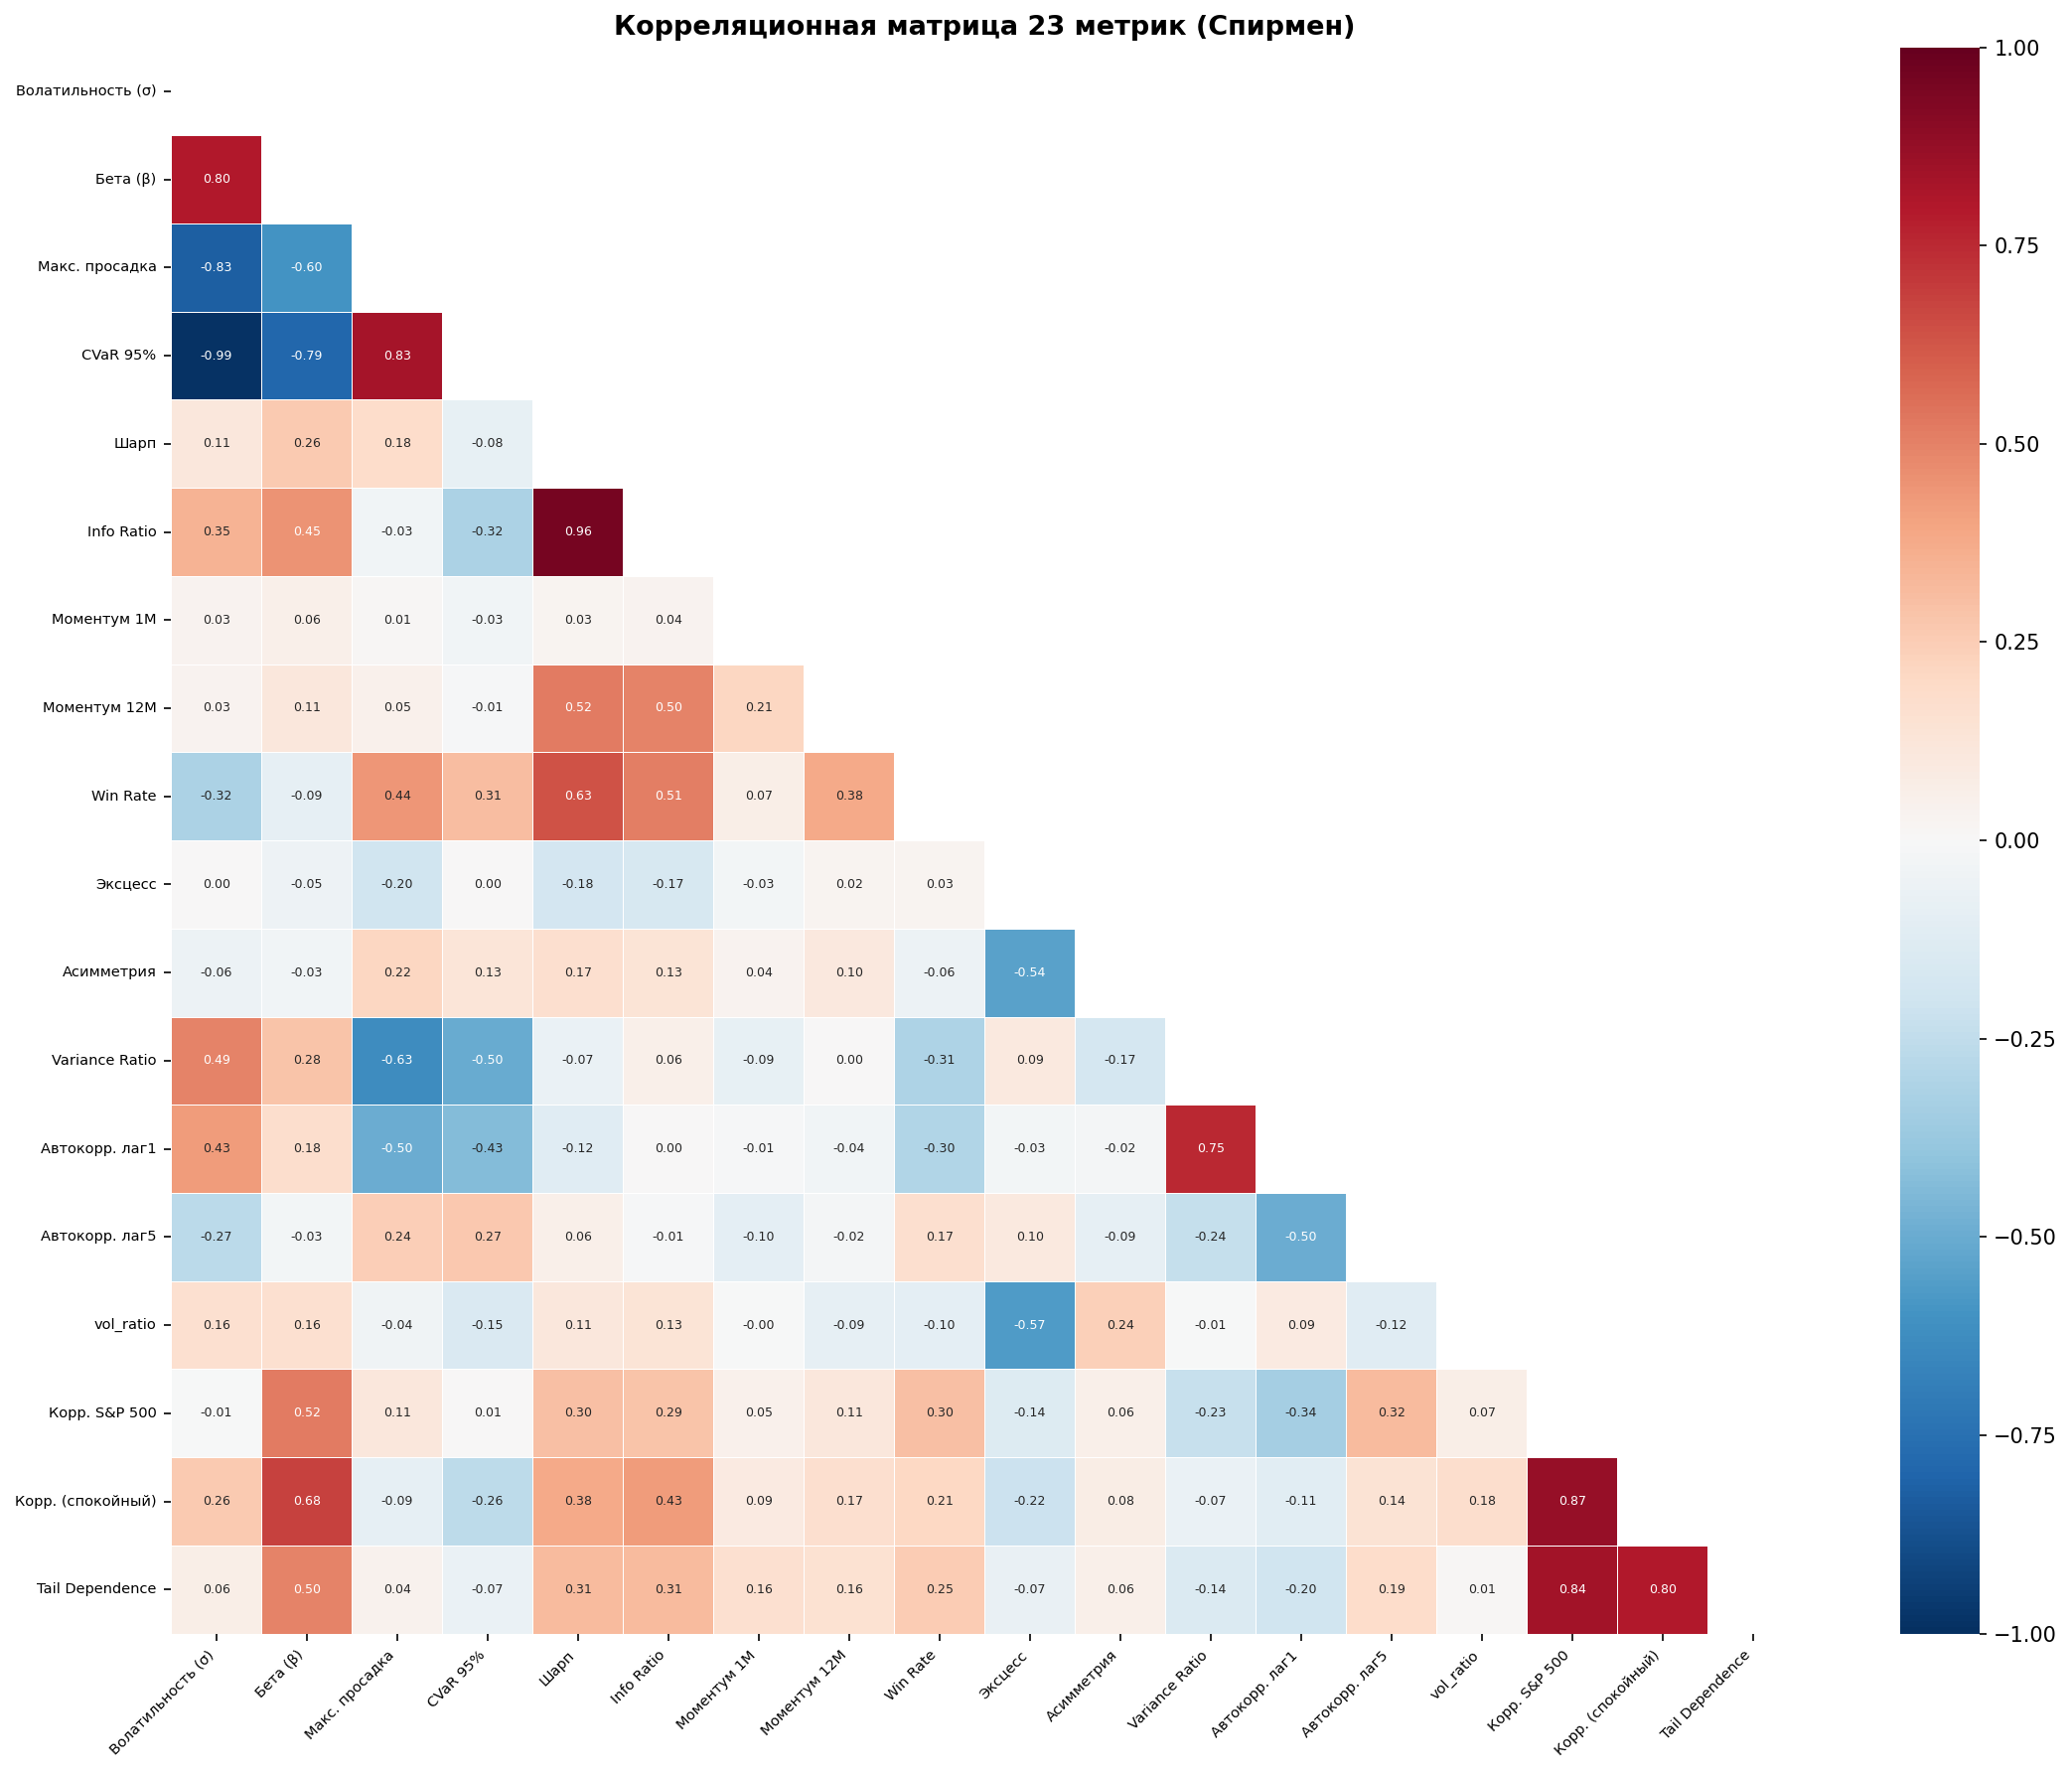

Пары с |ρ| > 0.7 (10 шт.):
        Метрика 1         Метрика 2  Корреляция
Волатильность (σ)          CVaR 95%      -0.986
             Шарп        Info Ratio       0.960
    Корр. S&P 500 Корр. (спокойный)       0.868
    Корр. S&P 500   Tail Dependence       0.842
   Макс. просадка          CVaR 95%       0.831
Волатильность (σ)    Макс. просадка      -0.826
Корр. (спокойный)   Tail Dependence       0.802
Волатильность (σ)          Бета (β)       0.801
         Бета (β)          CVaR 95%      -0.795
   Variance Ratio    Автокорр. лаг1       0.752


In [ ]:
corr = df[ALL_FEATURES].corr(method='spearman')
labels_disp = [LABELS.get(f, f) for f in ALL_FEATURES]

fig, ax = plt.subplots(figsize=(15, 12))
sns.heatmap(
    corr,
    mask=np.triu(np.ones_like(corr, dtype=bool)),
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    xticklabels=labels_disp, yticklabels=labels_disp,
    linewidths=0.4, annot_kws={'size': 6}, ax=ax
)
ax.set_title('Корреляционная матрица 23 метрик (Спирмен)',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig('plots/01_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Пары с |ρ| > 0.7
high_corr = []
for i in range(len(ALL_FEATURES)):
    for j in range(i+1, len(ALL_FEATURES)):
        r = corr.iloc[i, j]
        if abs(r) > 0.7:
            high_corr.append({
                'Метрика 1'  : LABELS[ALL_FEATURES[i]],
                'Метрика 2'  : LABELS[ALL_FEATURES[j]],
                'Корреляция' : round(r, 3)
            })

print(f"Пары с |ρ| > 0.7 ({len(high_corr)} шт.):")
if high_corr:
    print(pd.DataFrame(high_corr).sort_values(
        'Корреляция', key=abs, ascending=False
    ).to_string(index=False))
else:
    print("  Нет сильно коррелирующих пар ✓")

## 5. Корреляции внутри каждой группы

Проверяем внутреннюю согласованность: если все метрики
в группе сильно коррелируют — группа «избыточна».

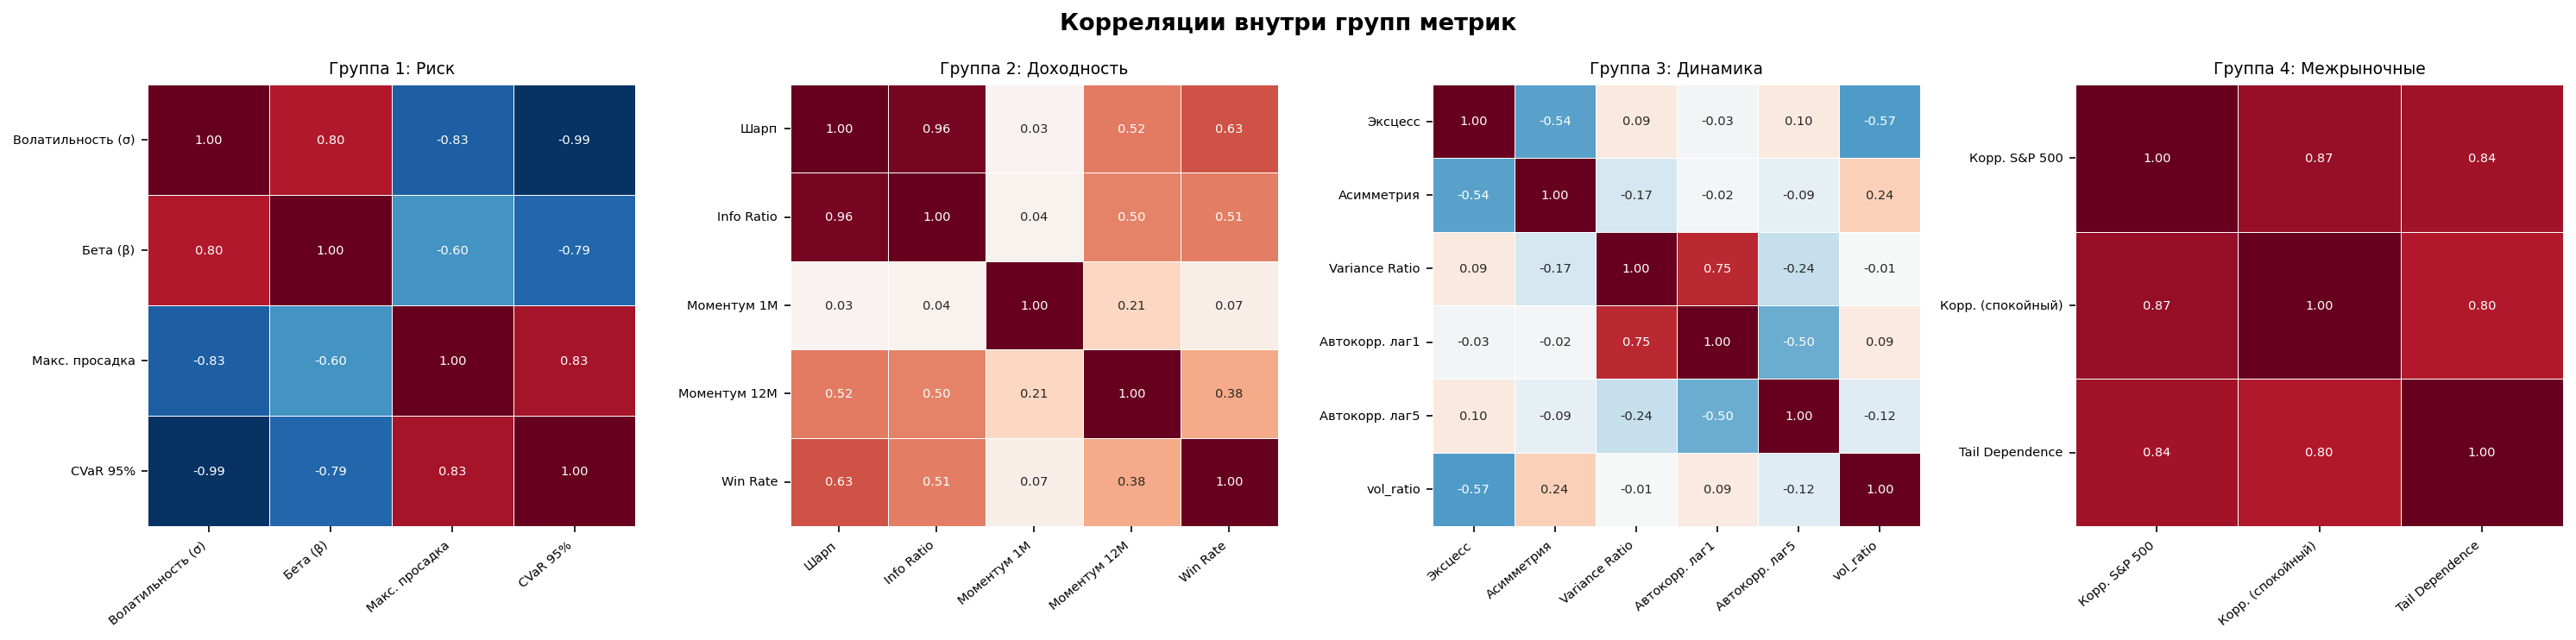

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Корреляции внутри групп метрик',
             fontsize=13, fontweight='bold')

for ax, (grp, feats) in zip(axes, FEATURE_GROUPS.items()):
    avail = [f for f in feats if f in df.columns]
    c     = df[avail].corr(method='spearman')
    lbls  = [LABELS.get(f, f) for f in avail]
    sns.heatmap(
        c, annot=True, fmt='.2f',
        cmap='RdBu_r', center=0, vmin=-1, vmax=1,
        xticklabels=lbls, yticklabels=lbls,
        linewidths=0.4, annot_kws={'size': 7},
        ax=ax, cbar=False
    )
    ax.set_title(GROUP_NAMES[grp], fontsize=9)
    plt.setp(ax.get_xticklabels(), rotation=40, ha='right', fontsize=7)
    plt.setp(ax.get_yticklabels(), rotation=0, fontsize=7)

plt.tight_layout()
plt.savefig('plots/01_intragroup_correlations.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 6. Новые метрики — специальный анализ

Для новых метрик добавляем содержательную интерпретацию.

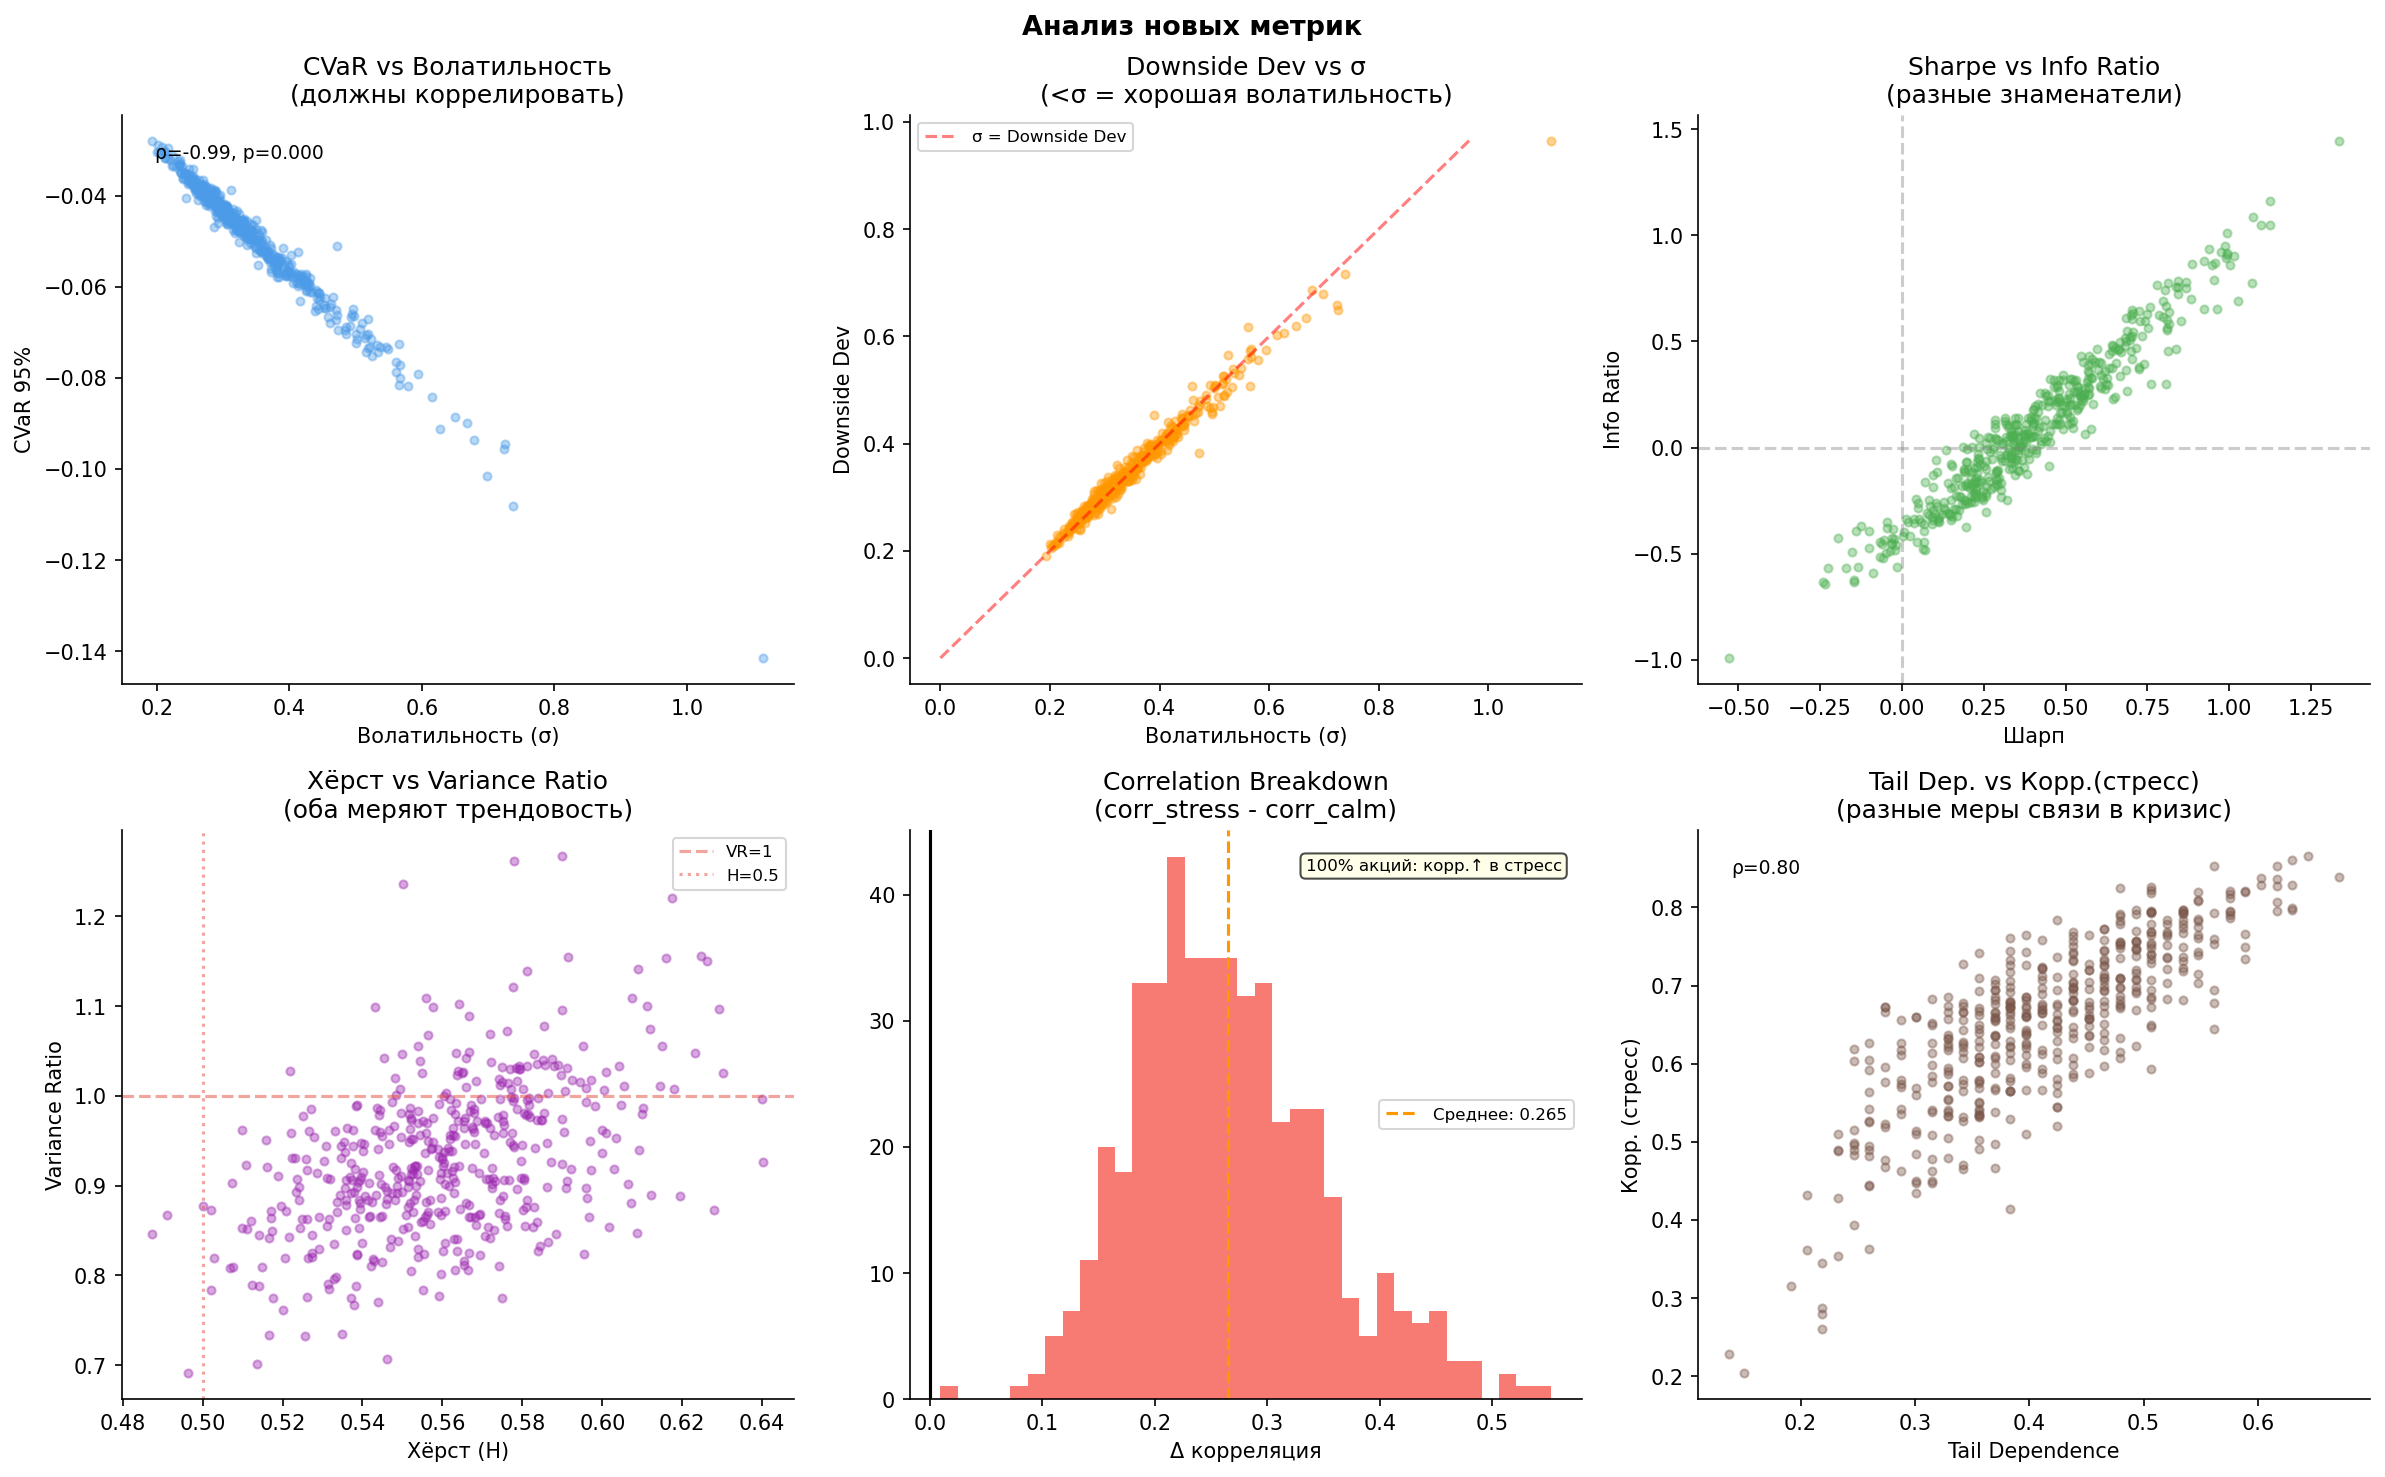

Correlation breakdown (corr_stress - corr_calm):
  Среднее: 0.265
  100% акций имеют более высокую корреляцию в стресс
  → Подтверждает эффект 'correlation breakdown' в кризис


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Анализ новых метрик',
             fontsize=13, fontweight='bold')

# 1. CVaR vs Sigma
ax = axes[0, 0]
ax.scatter(df['sigma'], df['cvar_95'], alpha=0.4, s=15, color='#4C9BE8')
ax.set_xlabel(LABELS['sigma'])
ax.set_ylabel(LABELS['cvar_95'])
ax.set_title('CVaR vs Волатильность\n(должны коррелировать)')
r, p = stats.spearmanr(df['sigma'].dropna(), df['cvar_95'].dropna())
ax.text(0.05, 0.95, f'ρ={r:.2f}, p={p:.3f}',
        transform=ax.transAxes, va='top', fontsize=9)

# 2. Downside Dev vs Sigma
ax = axes[0, 1]
ax.scatter(df['sigma'], df['downside_dev'], alpha=0.4, s=15, color='#FF9800')
ax.set_xlabel(LABELS['sigma'])
ax.set_ylabel(LABELS['downside_dev'])
ax.set_title('Downside Dev vs σ\n(<σ = хорошая волатильность)')
# Линия σ = downside_dev (если точки ниже — волатильность «хорошая»)
lim = min(df['sigma'].max(), df['downside_dev'].max())
ax.plot([0, lim], [0, lim], 'r--', alpha=0.5, label='σ = Downside Dev')
ax.legend(fontsize=8)

# 3. Sharpe vs Info Ratio
ax = axes[0, 2]
ax.scatter(df['sharpe'], df['info_ratio'], alpha=0.4, s=15, color='#4CAF50')
ax.set_xlabel(LABELS['sharpe'])
ax.set_ylabel(LABELS['info_ratio'])
ax.set_title('Sharpe vs Info Ratio\n(разные знаменатели)')
ax.axhline(0, color='gray', linestyle='--', alpha=0.4)
ax.axvline(0, color='gray', linestyle='--', alpha=0.4)

# 4. Hurst vs Variance Ratio
ax = axes[1, 0]
ax.scatter(df['hurst'], df['variance_ratio'], alpha=0.4, s=15, color='#9C27B0')
ax.set_xlabel(LABELS['hurst'])
ax.set_ylabel(LABELS['variance_ratio'])
ax.set_title('Хёрст vs Variance Ratio\n(оба меряют трендовость)')
ax.axhline(1.0, color='#e74c3c', linestyle='--', alpha=0.5, label='VR=1')
ax.axvline(0.5, color='#e74c3c', linestyle=':', alpha=0.5, label='H=0.5')
ax.legend(fontsize=8)

# 5. Correlation breakdown
ax = axes[1, 1]
breakdown = df['corr_stress'] - df['corr_calm']
ax.hist(breakdown.dropna(), bins=35, color='#F44336', alpha=0.7)
ax.axvline(0, color='black', linewidth=1.5)
ax.axvline(breakdown.mean(), color='#FF9800', linestyle='--',
           label=f'Среднее: {breakdown.mean():.3f}')
ax.set_title('Correlation Breakdown\n(corr_stress - corr_calm)')
ax.set_xlabel('Δ корреляция')
ax.legend(fontsize=8)
pct_positive = (breakdown > 0).mean() * 100
ax.text(0.97, 0.95, f'{pct_positive:.0f}% акций: корр.↑ в стресс',
        transform=ax.transAxes, ha='right', va='top', fontsize=8,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

# 6. Tail dependence vs corr_stress
ax = axes[1, 2]
ax.scatter(df['tail_dependence'], df['corr_stress'],
           alpha=0.4, s=15, color='#795548')
ax.set_xlabel(LABELS['tail_dependence'])
ax.set_ylabel(LABELS['corr_stress'])
ax.set_title('Tail Dep. vs Корр.(стресс)\n(разные меры связи в кризис)')
r, _ = stats.spearmanr(df['tail_dependence'].dropna(),
                        df['corr_stress'].dropna())
ax.text(0.05, 0.95, f'ρ={r:.2f}', transform=ax.transAxes,
        va='top', fontsize=9)

plt.tight_layout()
plt.savefig('plots/01_new_metrics_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Correlation breakdown (corr_stress - corr_calm):")
print(f"  Среднее: {breakdown.mean():.3f}")
print(f"  {pct_positive:.0f}% акций имеют более высокую корреляцию в стресс")
print(f"  → Подтверждает эффект 'correlation breakdown' в кризис")

## 7. Метрики по секторам

Если секторы различаются статистически значимо —
метрики несут реальный экономический смысл.

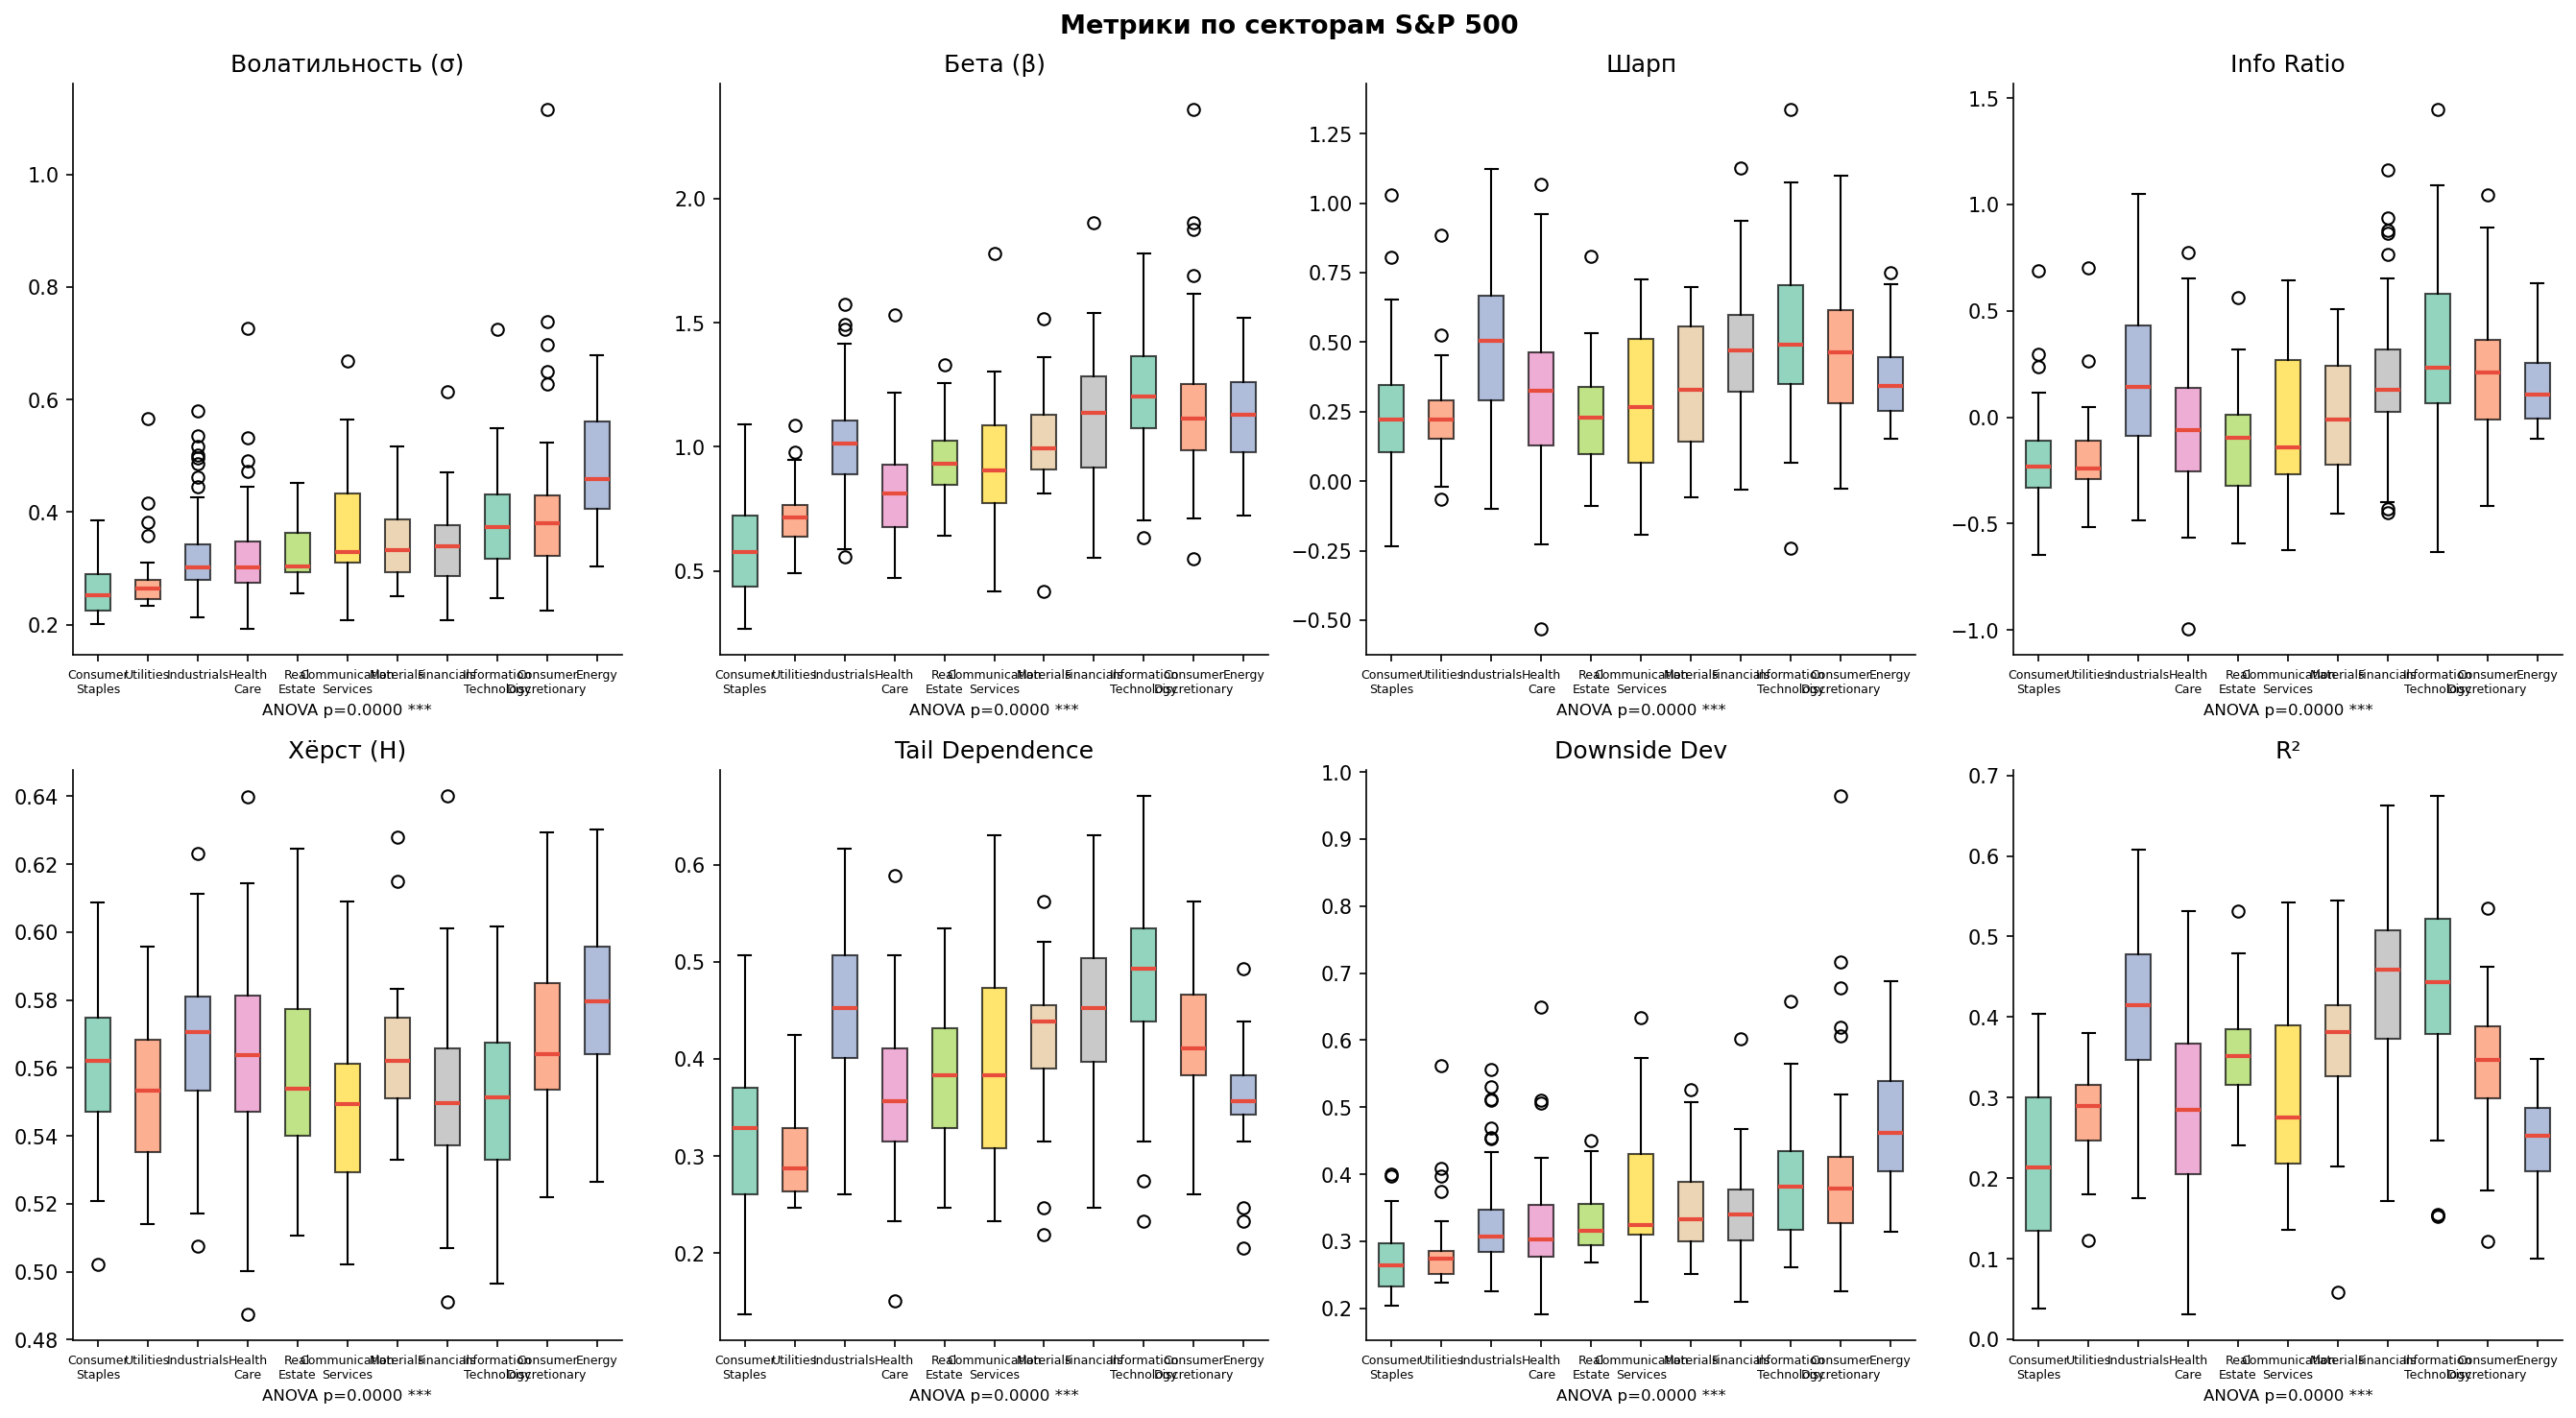

*** p<0.001  ** p<0.01  * p<0.05
→ Значимые различия = метрики несут экономический смысл


In [ ]:
key_feats = ['sigma','beta','sharpe','info_ratio',
             'hurst','tail_dependence','downside_dev','r_squared']
key_feats = [f for f in key_feats if f in df.columns]

sector_order = (
    df.groupby('sector')['sigma'].median()
    .sort_values().index.tolist()
)

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('Метрики по секторам S&P 500',
             fontsize=13, fontweight='bold')

for ax, feat in zip(axes.flatten(), key_feats):
    data_by_sec = [
        df[df['sector']==s][feat].dropna().values
        for s in sector_order
    ]
    bp = ax.boxplot(
        data_by_sec,
        labels=[s.replace(' ',"\n") for s in sector_order],
        patch_artist=True,
        medianprops=dict(color='#e74c3c', linewidth=2)
    )
    colors = sns.color_palette('Set2', len(sector_order))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_title(LABELS.get(feat, feat))
    ax.tick_params(axis='x', labelsize=6)

    # ANOVA
    clean = [d for d in data_by_sec if len(d) >= 3]
    if len(clean) >= 2:
        f_val, p_val = stats.f_oneway(*clean)
        sig = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else '*')
        ax.set_xlabel(f'ANOVA p={p_val:.4f} {sig}', fontsize=8)

plt.tight_layout()
plt.savefig('plots/01_metrics_by_sector.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("*** p<0.001  ** p<0.01  * p<0.05")
print("→ Значимые различия = метрики несут экономический смысл")

## 8. PCA — эффективная размерность

Сколько компонент нужно чтобы объяснить 80–90% дисперсии.
Обосновывает применимость K-Means (нет «проклятия размерности»).

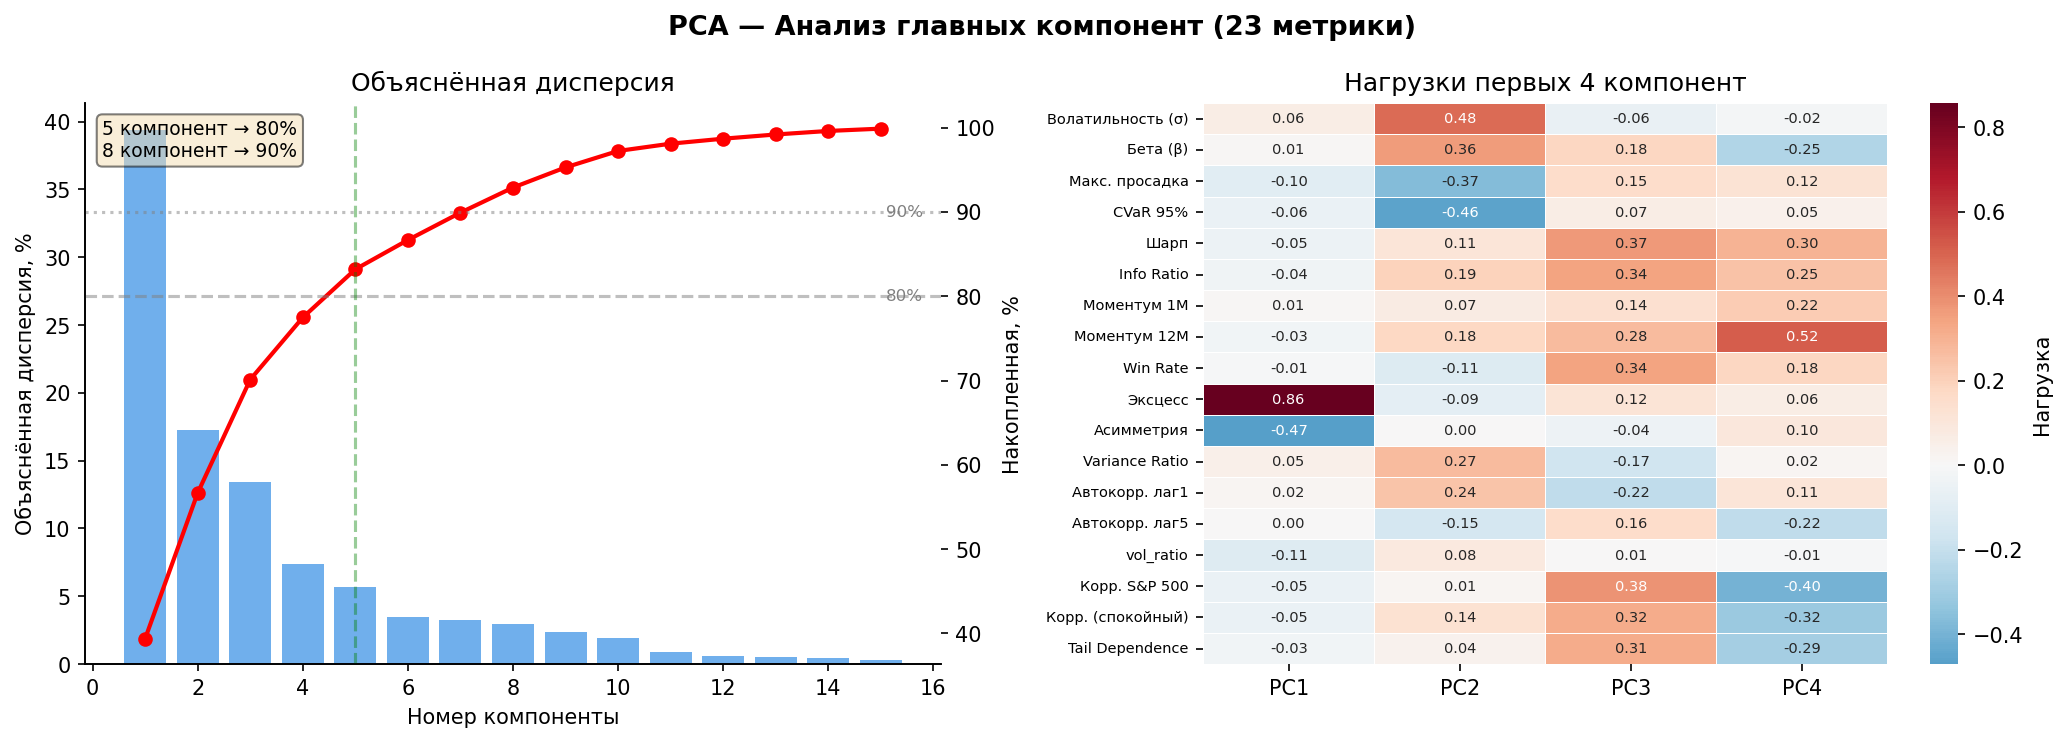

Компонент для 80% дисперсии: 5
Компонент для 90% дисперсии: 8
Исходных метрик:             18

→ Данные сжимаются с 18 до 5 измерений без большой потери информации
→ PC1 преимущественно отражает: ['Эксцесс', 'Асимметрия', 'vol_ratio']
→ PC2 преимущественно отражает: ['Волатильность (σ)', 'CVaR 95%', 'Макс. просадка']
→ PC3 преимущественно отражает: ['Корр. S&P 500', 'Шарп', 'Win Rate']
→ PC4 преимущественно отражает: ['Моментум 12М', 'Корр. S&P 500', 'Корр. (спокойный)']


In [ ]:
X_clean  = df[ALL_FEATURES].dropna()
X_scaled = RobustScaler().fit_transform(X_clean)

pca      = PCA(random_state=42)
pca.fit(X_scaled)
expl     = pca.explained_variance_ratio_
cumul    = np.cumsum(expl)

n_80 = int(np.argmax(cumul >= 0.80)) + 1
n_90 = int(np.argmax(cumul >= 0.90)) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PCA — Анализ главных компонент (23 метрики)',
             fontsize=13, fontweight='bold')

# Объяснённая дисперсия
ax = axes[0]
n_show = min(15, len(expl))
ax.bar(range(1, n_show+1), expl[:n_show]*100,
       color='#4C9BE8', alpha=0.8, label='Отдельная компонента')
ax2 = ax.twinx()
ax2.plot(range(1, n_show+1), cumul[:n_show]*100,
         'ro-', linewidth=2, label='Накопленная')
for thr, ls in [(80,'--'),(90,':')]:
    ax2.axhline(thr, color='gray', linestyle=ls, alpha=0.5)
    ax2.text(n_show+0.1, thr, f'{thr}%', va='center', fontsize=8, color='gray')
ax2.axvline(n_80, color='green', linestyle='--', alpha=0.4)
ax.set_xlabel('Номер компоненты')
ax.set_ylabel('Объяснённая дисперсия, %')
ax2.set_ylabel('Накопленная, %')
ax.set_title('Объяснённая дисперсия')
ax.text(0.02, 0.97,
        f'{n_80} компонент → 80%\n{n_90} компонент → 90%',
        transform=ax.transAxes, fontsize=9, va='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Нагрузки первых 4 компонент
ax = axes[1]
n_comp   = min(4, pca.n_components_)
loadings = pd.DataFrame(
    pca.components_[:n_comp].T,
    index=[LABELS.get(f, f) for f in ALL_FEATURES],
    columns=[f'PC{i+1}' for i in range(n_comp)]
)
sns.heatmap(
    loadings, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0,
    linewidths=0.3, annot_kws={'size': 7},
    ax=ax, cbar_kws={'label': 'Нагрузка'}
)
ax.set_title('Нагрузки первых 4 компонент')
plt.setp(ax.get_yticklabels(), fontsize=7)

plt.tight_layout()
plt.savefig('plots/01_pca.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Компонент для 80% дисперсии: {n_80}")
print(f"Компонент для 90% дисперсии: {n_90}")
print(f"Исходных метрик:             {len(ALL_FEATURES)}")
print(f"\n→ Данные сжимаются с {len(ALL_FEATURES)} до {n_80} "
      f"измерений без большой потери информации")
print(f"→ PC1 преимущественно отражает: "
      + str(loadings['PC1'].abs().nlargest(3).index.tolist()))
print(f"→ PC2 преимущественно отражает: "
      + str(loadings['PC2'].abs().nlargest(3).index.tolist()))

print(f"→ PC3 преимущественно отражает: "
      + str(loadings['PC3'].abs().nlargest(3).index.tolist()))

print(f"→ PC4 преимущественно отражает: "
      + str(loadings['PC4'].abs().nlargest(3).index.tolist()))



## 9. t-SNE — визуальная карта рынка до кластеризации

Если сгустки видны до запуска алгоритма — кластеры существуют объективно.

Вычисляем t-SNE (~1–2 мин)...


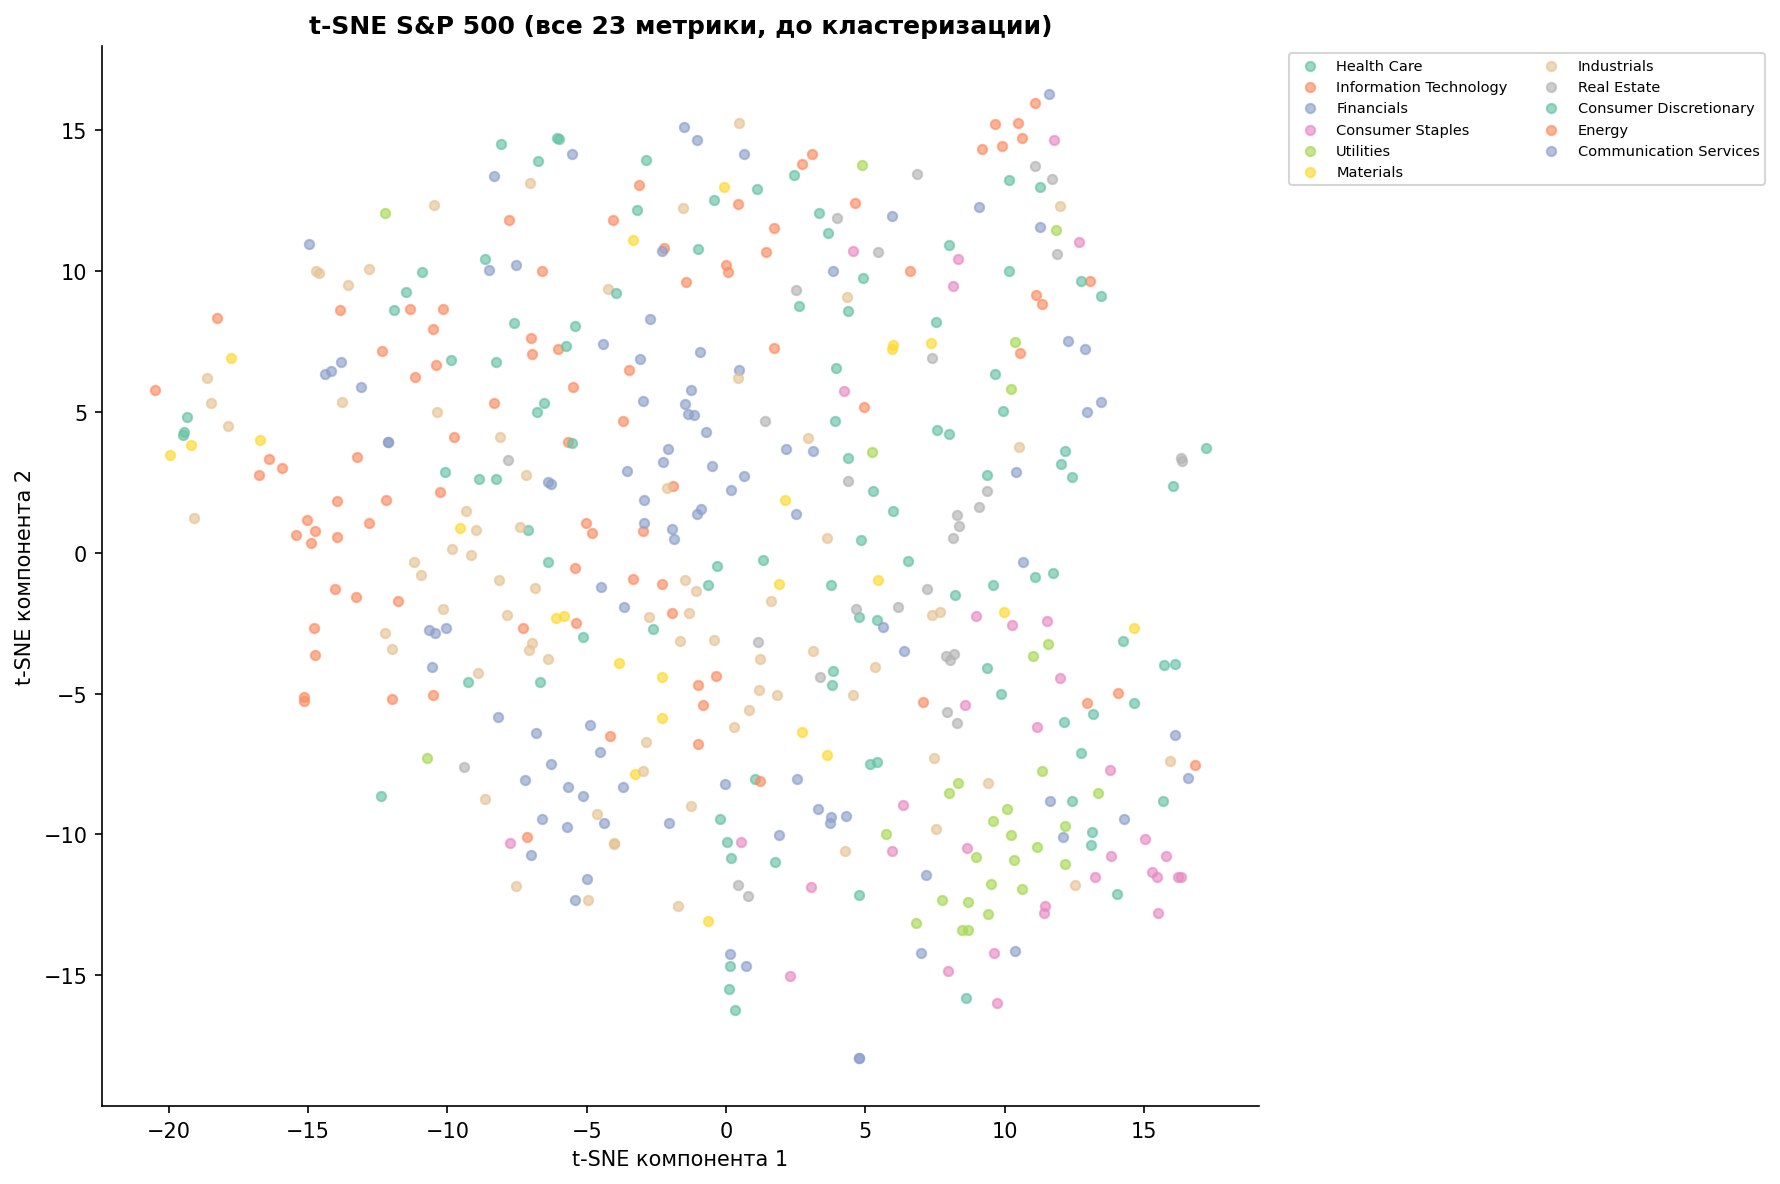

✓ plots/01_tsne_interactive.html | plots/01_tsne_static.png


In [ ]:
import plotly.express as px

print("Вычисляем t-SNE (~1–2 мин)...")
tsne   = TSNE(n_components=2, perplexity=40,
              learning_rate='auto', max_iter=1500, random_state=42)
coords = tsne.fit_transform(X_scaled)

tsne_df = pd.DataFrame({
    'x'      : coords[:, 0],
    'y'      : coords[:, 1],
    'ticker' : X_clean.index,
    'sector' : df.loc[X_clean.index, 'sector'],
    'name'   : df.loc[X_clean.index, 'name'],
})
for feat in ['sigma','beta','sharpe','hurst','info_ratio']:
    if feat in df.columns:
        tsne_df[LABELS[feat]] = df.loc[X_clean.index, feat].round(3).values

# Интерактивный
fig = px.scatter(
    tsne_df, x='x', y='y', color='sector',
    hover_name='ticker',
    hover_data=['name','sector'] +
               [LABELS[f] for f in ['sigma','beta','sharpe','hurst']
                if LABELS[f] in tsne_df.columns],
    title='t-SNE S&P 500 (до кластеризации, цвет = сектор)',
    color_discrete_sequence=px.colors.qualitative.Set2,
    width=900, height=650
)
fig.update_traces(marker=dict(size=6, opacity=0.75))
fig.update_layout(plot_bgcolor='#f8f9fa',
                  legend=dict(orientation='v', x=1.01))
fig.write_html('plots/01_tsne_interactive.html')
fig.show()

# Статичная для диплома
fig2, ax = plt.subplots(figsize=(12, 8))
sectors  = tsne_df['sector'].dropna().unique()
colors   = sns.color_palette('Set2', len(sectors))
for sec, color in zip(sectors, colors):
    mask = tsne_df['sector'] == sec
    ax.scatter(tsne_df.loc[mask,'x'], tsne_df.loc[mask,'y'],
               label=sec, alpha=0.65, s=20, color=color)
ax.set_title('t-SNE S&P 500 (все 23 метрики, до кластеризации)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('t-SNE компонента 1')
ax.set_ylabel('t-SNE компонента 2')
ax.legend(fontsize=7, ncol=2, bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.savefig('plots/01_tsne_static.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ plots/01_tsne_interactive.html | plots/01_tsne_static.png")

## 10. Итоговые выводы EDA

In [ ]:
print("=" * 60)
print("  ИТОГОВЫЕ ВЫВОДЫ EDA (23 метрики)")
print("=" * 60)
print(f"""
1. НОРМАЛЬНОСТЬ
   {len(ALL_FEATURES)-sum(normality.values())} из {len(ALL_FEATURES)} метрик — ненормальны.
   → Используем RobustScaler и корреляцию Спирмена.

2. НОВЫЕ МЕТРИКИ — КЛЮЧЕВЫЕ НАБЛЮДЕНИЯ
   • CVaR тесно связан с σ, но улавливает хвостовой риск
   • Downside Dev < σ у большинства акций (есть «хорошая» волатильность)
   • Info Ratio vs S&P: многие акции проигрывают бенчмарку (IR < 0)
   • Variance Ratio > 1 у многих акций → умеренная персистентность
   • Correlation breakdown: большинство акций коррелируют
     с рынком сильнее в стрессовый период

3. PCA
   {n_80} компонент объясняют 80% дисперсии ({len(ALL_FEATURES)} исходных метрик).
   Данные имеют относительно низкую эффективную размерность.
   PC1 ≈ риск/волатильность, PC2 ≈ динамика/трендовость.

4. СЕКТОРАЛЬНЫЕ РАЗЛИЧИЯ
   Все ключевые метрики значимо различаются по секторам (ANOVA).
   → Метрики несут реальный экономический смысл.

5. t-SNE
   Визуальные сгустки видны до кластеризации.
   → Кластерная структура существует объективно.
""")
print("=" * 60)
print("  Следующий шаг: notebook_03_exp1_risk.ipynb")
print("=" * 60)

  ИТОГОВЫЕ ВЫВОДЫ EDA (23 метрики)

1. НОРМАЛЬНОСТЬ
   14 из 18 метрик — ненормальны.
   → Используем RobustScaler и корреляцию Спирмена.

2. НОВЫЕ МЕТРИКИ — КЛЮЧЕВЫЕ НАБЛЮДЕНИЯ
   • CVaR тесно связан с σ, но улавливает хвостовой риск
   • Downside Dev < σ у большинства акций (есть «хорошая» волатильность)
   • Info Ratio vs S&P: многие акции проигрывают бенчмарку (IR < 0)
   • Variance Ratio > 1 у многих акций → умеренная персистентность
   • Correlation breakdown: большинство акций коррелируют
     с рынком сильнее в стрессовый период

3. PCA
   5 компонент объясняют 80% дисперсии (18 исходных метрик).
   Данные имеют относительно низкую эффективную размерность.
   PC1 ≈ риск/волатильность, PC2 ≈ динамика/трендовость.

4. СЕКТОРАЛЬНЫЕ РАЗЛИЧИЯ
   Все ключевые метрики значимо различаются по секторам (ANOVA).
   → Метрики несут реальный экономический смысл.

5. t-SNE
   Визуальные сгустки видны до кластеризации.
   → Кластерная структура существует объективно.

  Следующий шаг: noteboo